In [1]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
import pandas as pd
import time
import random
from datetime import datetime

# ---------------- SETUP ----------------
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))
driver.maximize_window()

# ---------------- LIST OF URLs ----------------
urls = [
    "https://www.practo.com/hyderabad/hospital/hegde-hospital-madhapur/group/doctors?city=hyderabad&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=675874&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=675874",
    "https://www.practo.com/hyderabad/hospital/vignesh-nursing-home-kukatpally-1/group/doctors?city=hyderabad&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1135067&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1135067",
    "https://www.practo.com/hyderabad/hospital/sankhya-hospitals-kukatpally/group/doctors?city=hyderabad&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=687613&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=687613",
    "https://www.practo.com/chennai/hospital/sims-hospital-vadapalani-4/group/doctors?city=chennai&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1192041&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1192041",
    "https://www.practo.com/chennai/hospital/apollo-hospital-34/group/doctors?city=chennai&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=947298&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=947298",
    "https://www.practo.com/chennai/hospital/new-hope-medical-centre-kilpauk-1/group/doctors?city=chennai&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=708029&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=708029",
    "https://www.practo.com/chennai/hospital/apollo-first-med-hospital-kilpauk/group/doctors?city=chennai&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1006874&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1006874",
    "https://www.practo.com/bangalore/hospital/apollo-cradle-jayanagar-1/group/doctors?city=bangalore&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1122944&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1122944",
    "https://www.practo.com/chennai/hospital/miot-international-hospital-manapakkam-2/group/doctors?city=chennai&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1011230&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1011230",
    "https://www.practo.com/chennai/hospital/apollo-speciality-hospitals-vanagaram/group/doctors?city=chennai&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1129485&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1129485",
    "https://www.practo.com/chennai/hospital/cloud-nine-hospital-tnagar/group/doctors?city=chennai&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=681187&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=681187",
    "https://www.practo.com/chennai/hospital/motherhood-hospital-chennai-alwarpet/group/doctors?city=chennai&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1120251&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1120251",
    "https://www.practo.com/chennai/hospital/be-well-hospitall-t-nagar/group/doctors?city=chennai&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=707228&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=707228",
    "https://www.practo.com/chennai/hospital/apollo-hospitals-greams-road-3/group/doctors?city=chennai&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=792837&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=792837",
    "https://www.practo.com/chennai/hospital/apollo-speciality-cancer-hospital/group/doctors?city=chennai&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1005781&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1005781"
    # add more hospital URLs here
]

all_data = []

# ---------------- POSSIBLE WORKING HOURS ----------------
working_hours_normal = [
    "9:00 AM - 6:00 PM",
    "10:00 AM - 8:00 PM",
    "8:00 AM - 4:00 PM",
    "11:00 AM - 7:00 PM"
]

# ---------------- FUNCTION TO CALCULATE DURATION ----------------
def calculate_duration(time_str):
    if time_str == "24x7":
        return 24
    try:
        start, end = time_str.split(" - ")
        start_dt = datetime.strptime(start, "%I:%M %p")
        end_dt = datetime.strptime(end, "%I:%M %p")
        duration = (end_dt - start_dt).seconds / 3600
        if duration < 0:  # handle cases like 10 PM - 6 AM
            duration += 24
        return duration
    except:
        return None

# ---------------- FUNCTION TO GET TIMING CATEGORY ----------------
def get_timing_category(time_str):
    if time_str == "24x7":
        return "24x7"
    try:
        start, end = time_str.split(" - ")
        start_dt = datetime.strptime(start, "%I:%M %p")
        if start_dt.hour < 12:
            return "Morning"
        else:
            return "Evening"
    except:
        return ""

# ---------------- LOOP THROUGH URLs ----------------
for url in urls:
    driver.get(url)
    time.sleep(5)  # wait for page to load

    doctors = driver.find_elements(By.CLASS_NAME, "info-section")

    # randomly assign some doctors as 24x7
    indices_24x7 = random.sample(range(len(doctors)), k=min(2, len(doctors)))

    for idx, doc in enumerate(doctors):
        try:
            name = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="doctor_name"]').text
        except:
            name = ""

        try:
            specialization = doc.find_element(By.XPATH,'.//div[@class="u-d-flex"]/span').text
        except:
            specialization = ""

        try:
            experience = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="doctor_experience"]').text
        except:
            experience = ""

        try:
            locality = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="practice_locality"]').text
        except:
            locality = ""

        try:
            city = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="practice_city"]').text
        except:
            city = ""

        try:
            clinic = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="doctor_clinic_name"]').text
        except:
            clinic = ""

        try:
            fee = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="consultation_fee"]').text
        except:
            fee = ""

        try:
            recommendation = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="doctor_recommendation"]').text
        except:
            recommendation = ""

        # assign working hours
        if idx in indices_24x7:
            working_hours = "24x7"
        else:
            working_hours = random.choice(working_hours_normal)

        # timing category and duration
        timing_category = get_timing_category(working_hours)
        time_duration = calculate_duration(working_hours)

        all_data.append([
            name,
            specialization,
            experience,
            locality,
            city,
            clinic,
            fee,
            recommendation,
            working_hours,
            timing_category,
            time_duration
        ])

# ---------------- CREATE DATAFRAME ----------------
df = pd.DataFrame(all_data, columns=[
    "Doctor_Name",
    "Specialization",
    "Experience",
    "Locality",
    "City",
    "Hospital_Name",
    "Consultation_Fee",
    "Recommendation",
    "Working_Hours",
    "Timing_Category",
    "Time_Duration"
])

driver.quit()

print(df)

                   Doctor_Name                              Specialization  \
0            Dr. Vandana Hegde                      Infertility Specialist   
1              Dr. B C Mounica                   Gynecologist/Obstetrician   
2    Dr. Jasmine Ramesh Salkar                   Gynecologist/Obstetrician   
3               Dr. Soumya H R  Reproductive Endocrinologist (Infertility)   
4          Dr. Akshita Agarwal                   Gynecologist/Obstetrician   
..                         ...                                         ...   
138    Dr. Sanjay Chandrasekar                           General Physician   
139            Dr. Ramanan S G                           General Physician   
140          Dr. Vijayakumar G                           General Physician   
141              Dr. Mahadev P                                  Oncologist   
142       Dr. Sowminarayanan R                           General Physician   

                      Experience    Locality       City  \
0   

In [2]:
df

,Doctor_Name,Specialization,Experience,Locality,City,Hospital_Name,Consultation_Fee,Recommendation,Working_Hours,Timing_Category,Time_Duration
0,Dr. Vandana Hegde,Infertility Specialist,23 years experience overall,"Madhapur,",Hyderabad,Hegde Hospital,₹800,93%,11:00 AM - 7:00 PM,Morning,8.0
1,Dr. B C Mounica,Gynecologist/Obstetrician,10 years experience overall,"Madhapur,",Hyderabad,Hegde Hospital,₹600,,10:00 AM - 8:00 PM,Morning,10.0
2,Dr. Jasmine Ramesh Salkar,Gynecologist/Obstetrician,23 years experience overall,"Madhapur,",Hyderabad,Hegde Hospital,₹800,95%,24x7,24x7,24.0
3,Dr. Soumya H R,Reproductive Endocrinologist (Infertility),8 years experience overall,"Madhapur,",Hyderabad,Hegde Hospital,₹600,,8:00 AM - 4:00 PM,Morning,8.0
4,Dr. Akshita Agarwal,Gynecologist/Obstetrician,9 years experience overall,"Madhapur,",Hyderabad,Hegde Hospital,₹600,100%,10:00 AM - 8:00 PM,Morning,10.0
...,...,...,...,...,...,...,...,...,...,...,...
138,Dr. Sanjay Chandrasekar,General Physician,33 years experience overall,"Teynampet,",Chennai,Apollo Cancer Centres Chennai,₹1500,100%,10:00 AM - 8:00 PM,Morning,10.0
139,Dr. Ramanan S G,General Physician,30 years experience overall,"Teynampet,",Chennai,Apollo Cancer Centres Chennai,₹1500,100%,8:00 AM - 4:00 PM,Morning,8.0
140,Dr. Vijayakumar G,General Physician,44 years experience overall,"Teynampet,",Chennai,Apollo Cancer Centres Chennai,₹1000,,9:00 AM - 6:00 PM,Morning,9.0
141,Dr. Mahadev P,Oncologist,37 years experience overall,"Teynampet,",Chennai,Apollo Cancer Centres Chennai,₹3000,100%,11:00 AM - 7:00 PM,Morning,8.0


In [3]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
import pandas as pd
import time
import random
from datetime import datetime

# ---------------- SETUP ----------------
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))
driver.maximize_window()

# ---------------- LIST OF URLs ----------------
urls = [
    "https://www.practo.com/chennai/hospital/be-well-hospitall-t-nagar/group/doctors?city=chennai&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=707228&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=707228",
    "https://www.practo.com/bangalore/hospital/columbia-asia-hospital1-whitefield/group/doctors?city=bangalore&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1131816&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1131816",
    "https://www.practo.com/bangalore/hospital/manipal-hospital-yeshwanthpur/group/doctors?city=bangalore&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1131812&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1131812",
    "https://www.practo.com/bangalore/hospital/koshys-hospital-ramamurthy-nagar-2-1/group/doctors?city=bangalore&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=927402&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=927402",
    "https://www.practo.com/bangalore/hospital/motherhood-hospital-indiranagar/group/doctors?city=bangalore&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=625693&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=625693",
    "https://www.practo.com/bangalore/hospital/motherhood-hospital-whitefield-3/group/doctors?city=chennai&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1106420&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1106420",
    "https://www.practo.com/bangalore/hospital/dr-malathi-manipal-hospital-jayanagar/group/doctors?city=chennai&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1041383&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1041383",
    "https://www.practo.com/bangalore/hospital/sagar-hospitals-banashankari/group/doctors?city=chennai&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=930035&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=930035",
    "https://www.practo.com/chennai/hospital/soundarapandian-bone-and-joint-hospital-research-institute-anna-nagar/group/doctors?city=chennai&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=645228&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=645228",
    "https://www.practo.com/mumbai/hospital/dr-l-h-hiranandani-hospital-powai1/group/doctors?city=mumbai&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=725564&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=725564",
    "https://www.practo.com/mumbai/hospital/umrao-hospital-mira-road/group/doctors?city=mumbai&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=679125&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=679125",
    "https://www.practo.com/mumbai/hospital/cloudnine-hospital-malad-1-malad-west/group/doctors?city=mumbai&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1053187&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1053187",
    "https://www.practo.com/bangalore/hospital/bgs-global-hospital-kengeri-6/group/doctors?city=bangalore&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=664585&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=664585",
    "https://www.practo.com/delhi/hospital/blk-hospital-pusa-road/group/doctors?city=delhi&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=680128&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=680128",
    "https://www.practo.com/delhi/hospital/max-multi-speciality-center-panchsheel-park/group/doctors?city=delhi&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=670997&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=670997",
    "https://www.practo.com/delhi/hospital/sci-international-hospital-greater-kailash-part-1-2/group/doctors?city=delhi&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1129924&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1129924"
    
]

all_data = []

# ---------------- POSSIBLE WORKING HOURS ----------------
working_hours_normal = [
    "9:00 AM - 6:00 PM",
    "10:00 AM - 8:00 PM",
    "8:00 AM - 4:00 PM",
    "11:00 AM - 7:00 PM"
]

# ---------------- FUNCTION TO CALCULATE DURATION ----------------
def calculate_duration(time_str):
    if time_str == "24x7":
        return 24
    try:
        start, end = time_str.split(" - ")
        start_dt = datetime.strptime(start, "%I:%M %p")
        end_dt = datetime.strptime(end, "%I:%M %p")
        duration = (end_dt - start_dt).seconds / 3600
        if duration < 0:  # handle cases like 10 PM - 6 AM
            duration += 24
        return duration
    except:
        return None

# ---------------- FUNCTION TO GET TIMING CATEGORY ----------------
def get_timing_category(time_str):
    if time_str == "24x7":
        return "24x7"
    try:
        start, end = time_str.split(" - ")
        start_dt = datetime.strptime(start, "%I:%M %p")
        if start_dt.hour < 12:
            return "Morning"
        else:
            return "Evening"
    except:
        return ""

# ---------------- LOOP THROUGH URLs ----------------
for url in urls:
    driver.get(url)
    time.sleep(5)  # wait for page to load

    doctors = driver.find_elements(By.CLASS_NAME, "info-section")

    # randomly assign some doctors as 24x7
    indices_24x7 = random.sample(range(len(doctors)), k=min(2, len(doctors)))

    for idx, doc in enumerate(doctors):
        try:
            name = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="doctor_name"]').text
        except:
            name = ""

        try:
            specialization = doc.find_element(By.XPATH,'.//div[@class="u-d-flex"]/span').text
        except:
            specialization = ""

        try:
            experience = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="doctor_experience"]').text
        except:
            experience = ""

        try:
            locality = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="practice_locality"]').text
        except:
            locality = ""

        try:
            city = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="practice_city"]').text
        except:
            city = ""

        try:
            clinic = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="doctor_clinic_name"]').text
        except:
            clinic = ""

        try:
            fee = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="consultation_fee"]').text
        except:
            fee = ""

        try:
            recommendation = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="doctor_recommendation"]').text
        except:
            recommendation = ""

        # assign working hours
        if idx in indices_24x7:
            working_hours = "24x7"
        else:
            working_hours = random.choice(working_hours_normal)

        # timing category and duration
        timing_category = get_timing_category(working_hours)
        time_duration = calculate_duration(working_hours)

        all_data.append([
            name,
            specialization,
            experience,
            locality,
            city,
            clinic,
            fee,
            recommendation,
            working_hours,
            timing_category,
            time_duration
        ])

# ---------------- CREATE DATAFRAME ----------------
df1 = pd.DataFrame(all_data, columns=[
    "Doctor_Name",
    "Specialization",
    "Experience",
    "Locality",
    "City",
    "Hospital_Name",
    "Consultation_Fee",
    "Recommendation",
    "Working_Hours",
    "Timing_Category",
    "Time_Duration"
])

driver.quit()
df1

,Doctor_Name,Specialization,Experience,Locality,City,Hospital_Name,Consultation_Fee,Recommendation,Working_Hours,Timing_Category,Time_Duration
0,Dr. jayasudha k,General Physician,25 years experience overall,"T Nagar,",Chennai,Be Well Hospital,Free Consultation,,24x7,24x7,24.0
1,"Dr. RANJINI,",General Physician,15 years experience overall,"T Nagar,",Chennai,Be Well Hospital,Free Consultation,,10:00 AM - 8:00 PM,Morning,10.0
2,"Dr. DEEPAK CHAKRAVARTHY,",General Physician,9 years experience overall,"T Nagar,",Chennai,Be Well Hospital,Free Consultation,,9:00 AM - 6:00 PM,Morning,9.0
3,"Dr. ALLAN DEEPAK,",General Physician,10 years experience overall,"T Nagar,",Chennai,Be Well Hospital,Free Consultation,,11:00 AM - 7:00 PM,Morning,8.0
4,Dr. DEEPAK AVINASH,General Physician,12 years experience overall,"T Nagar,",Chennai,Be Well Hospital,Free Consultation,,11:00 AM - 7:00 PM,Morning,8.0
...,...,...,...,...,...,...,...,...,...,...,...
145,Dr. Mandeep Singh,Orthopedist,26 years experience overall,"Greater Kailash Part 1,",Delhi,SCI International Hospital,₹1500,86%,9:00 AM - 6:00 PM,Morning,9.0
146,Dr. Sanjeev Kumar Gupta,Laparoscopic Surgeon,29 years experience overall,"Greater Kailash Part 1,",Delhi,SCI International Hospital,₹800,67%,8:00 AM - 4:00 PM,Morning,8.0
147,Dr. Vishal Dutt Gour,Urologist,28 years experience overall,"Greater Kailash Part 1,",Delhi,SCI International Hospital,₹1500,92%,9:00 AM - 6:00 PM,Morning,9.0
148,Dr. Sreesti Jaiswal,Gynecologist/Obstetrician,14 years experience overall,"Greater Kailash Part 1,",Delhi,SCI International Hospital,₹1200,100%,9:00 AM - 6:00 PM,Morning,9.0


In [4]:
df1

,Doctor_Name,Specialization,Experience,Locality,City,Hospital_Name,Consultation_Fee,Recommendation,Working_Hours,Timing_Category,Time_Duration
0,Dr. jayasudha k,General Physician,25 years experience overall,"T Nagar,",Chennai,Be Well Hospital,Free Consultation,,24x7,24x7,24.0
1,"Dr. RANJINI,",General Physician,15 years experience overall,"T Nagar,",Chennai,Be Well Hospital,Free Consultation,,10:00 AM - 8:00 PM,Morning,10.0
2,"Dr. DEEPAK CHAKRAVARTHY,",General Physician,9 years experience overall,"T Nagar,",Chennai,Be Well Hospital,Free Consultation,,9:00 AM - 6:00 PM,Morning,9.0
3,"Dr. ALLAN DEEPAK,",General Physician,10 years experience overall,"T Nagar,",Chennai,Be Well Hospital,Free Consultation,,11:00 AM - 7:00 PM,Morning,8.0
4,Dr. DEEPAK AVINASH,General Physician,12 years experience overall,"T Nagar,",Chennai,Be Well Hospital,Free Consultation,,11:00 AM - 7:00 PM,Morning,8.0
...,...,...,...,...,...,...,...,...,...,...,...
145,Dr. Mandeep Singh,Orthopedist,26 years experience overall,"Greater Kailash Part 1,",Delhi,SCI International Hospital,₹1500,86%,9:00 AM - 6:00 PM,Morning,9.0
146,Dr. Sanjeev Kumar Gupta,Laparoscopic Surgeon,29 years experience overall,"Greater Kailash Part 1,",Delhi,SCI International Hospital,₹800,67%,8:00 AM - 4:00 PM,Morning,8.0
147,Dr. Vishal Dutt Gour,Urologist,28 years experience overall,"Greater Kailash Part 1,",Delhi,SCI International Hospital,₹1500,92%,9:00 AM - 6:00 PM,Morning,9.0
148,Dr. Sreesti Jaiswal,Gynecologist/Obstetrician,14 years experience overall,"Greater Kailash Part 1,",Delhi,SCI International Hospital,₹1200,100%,9:00 AM - 6:00 PM,Morning,9.0


In [5]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
import pandas as pd
import time
import random
from datetime import datetime

# ---------------- SETUP ----------------
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))
driver.maximize_window()

# ---------------- LIST OF URLs ----------------
urls = [
    "https://www.practo.com/delhi/hospital/max-smart-super-specialty-hospital-saket-2/group/doctors?city=delhi&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=702104&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=702104",
    "https://www.practo.com/delhi/hospital/apollo-cradle-nehru-place-delhi-nehru-place/group/doctors?city=chennai&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1122370&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1122370",
    "https://www.practo.com/search/hospitals?results_type=hospital&q=%5B%7B%22word%22%3A%22hospital%22%2C%22autocompleted%22%3Atrue%2C%22category%22%3A%22type%22%7D%5D&city=Delhi",
    "https://www.practo.com/delhi/hospital/kesar-hospital-shalimar-bagh-1/group/doctors?city=chennai&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1122671&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1122671",
    "https://www.practo.com/noida/hospital/indogulf-hospital-and-diagnostics-sector-19/group/doctors?city=noida&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1137224&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1137224",
    "https://www.practo.com/noida/hospital/cloudnine-fertility-gurgaon-gurgaon-sector-47/group/doctors?city=noida&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1156528&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1156528",
    "https://www.practo.com/noida/hospital/cloudnine-hospital-noida-sector-51/group/doctors?city=chennai&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1220785&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1220785",
    "https://www.practo.com/gurgaon/hospital/cloudnine-hospital-sector-47/group/doctors?city=gurgaon&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1156172&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1156172",
    "https://www.practo.com/gurgaon/hospital/manipal-hospital-palam-vihar/group/doctors?city=gurgaon&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=783910&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=783910",
    "https://www.practo.com/gurgaon/hospital/apollo-cradle-gurgaon-sector-14-2/group/doctors?city=gurgaon&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=715154&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=715154",
    "https://www.practo.com/gurgaon/hospital/max-hospital-sushant-lok-i-2/group/doctors?city=gurgaon&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=710420&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=710420",
    "https://www.practo.com/gurgaon/hospital/crystal-clinic-gurgaon-sector-15/group/doctors?city=chennai&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1157872&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1157872",
    "https://www.practo.com/gurgaon/hospital/sparsh-orthopaedics-and-sports-injury-centre-sohna-road/group/doctors?city=chennai&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1112124&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1112124",
    "https://www.practo.com/kolkata/hospital/amri-hospital-mukundapur-1/group/doctors?city=kolkata&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1250516&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1250516",
    "https://www.practo.com/kolkata/hospital/amri-hospitals-salt-lake-3/group/doctors?city=kolkata&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=735842&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=735842",
    "https://www.practo.com/kolkata/hospital/amri-dhakuria/group/doctors?city=kolkata&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1033173&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1033173",
    
]

all_data = []

# ---------------- POSSIBLE WORKING HOURS ----------------
working_hours_normal = [
    "9:00 AM - 6:00 PM",
    "10:00 AM - 8:00 PM",
    "8:00 AM - 4:00 PM",
    "11:00 AM - 7:00 PM"
]

# ---------------- FUNCTION TO CALCULATE DURATION ----------------
def calculate_duration(time_str):
    if time_str == "24x7":
        return 24
    try:
        start, end = time_str.split(" - ")
        start_dt = datetime.strptime(start, "%I:%M %p")
        end_dt = datetime.strptime(end, "%I:%M %p")
        duration = (end_dt - start_dt).seconds / 3600
        if duration < 0:  # handle cases like 10 PM - 6 AM
            duration += 24
        return duration
    except:
        return None

# ---------------- FUNCTION TO GET TIMING CATEGORY ----------------
def get_timing_category(time_str):
    if time_str == "24x7":
        return "24x7"
    try:
        start, end = time_str.split(" - ")
        start_dt = datetime.strptime(start, "%I:%M %p")
        if start_dt.hour < 12:
            return "Morning"
        else:
            return "Evening"
    except:
        return ""

# ---------------- LOOP THROUGH URLs ----------------
for url in urls:
    driver.get(url)
    time.sleep(5)  # wait for page to load

    doctors = driver.find_elements(By.CLASS_NAME, "info-section")

    # randomly assign some doctors as 24x7
    indices_24x7 = random.sample(range(len(doctors)), k=min(2, len(doctors)))

    for idx, doc in enumerate(doctors):
        try:
            name = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="doctor_name"]').text
        except:
            name = ""

        try:
            specialization = doc.find_element(By.XPATH,'.//div[@class="u-d-flex"]/span').text
        except:
            specialization = ""

        try:
            experience = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="doctor_experience"]').text
        except:
            experience = ""

        try:
            locality = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="practice_locality"]').text
        except:
            locality = ""

        try:
            city = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="practice_city"]').text
        except:
            city = ""

        try:
            clinic = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="doctor_clinic_name"]').text
        except:
            clinic = ""

        try:
            fee = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="consultation_fee"]').text
        except:
            fee = ""

        try:
            recommendation = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="doctor_recommendation"]').text
        except:
            recommendation = ""

        # assign working hours
        if idx in indices_24x7:
            working_hours = "24x7"
        else:
            working_hours = random.choice(working_hours_normal)

        # timing category and duration
        timing_category = get_timing_category(working_hours)
        time_duration = calculate_duration(working_hours)

        all_data.append([
            name,
            specialization,
            experience,
            locality,
            city,
            clinic,
            fee,
            recommendation,
            working_hours,
            timing_category,
            time_duration
        ])

# ---------------- CREATE DATAFRAME ----------------
df2 = pd.DataFrame(all_data, columns=[
    "Doctor_Name",
    "Specialization",
    "Experience",
    "Locality",
    "City",
    "Hospital_Name",
    "Consultation_Fee",
    "Recommendation",
    "Working_Hours",
    "Timing_Category",
    "Time_Duration"
])

driver.quit()
df2

,Doctor_Name,Specialization,Experience,Locality,City,Hospital_Name,Consultation_Fee,Recommendation,Working_Hours,Timing_Category,Time_Duration
0,Dr. Rommel Tickoo,General Physician,29 years experience overall,"Saket,",Delhi,Max Super Speciality Hospital - Saket East Wing,₹2000,93%,8:00 AM - 4:00 PM,Morning,8.0
1,Dr. Shefali Sardana,Oncologist,14 years experience overall,"Saket,",Delhi,Max Super Speciality Hospital - Saket East Wing,₹1500,67%,24x7,24x7,24.0
2,Dr. Sumit Sethi,General Physician,26 years experience overall,"Saket,",Delhi,Max Super Speciality Hospital - Saket East Wing,₹2000,,24x7,24x7,24.0
3,Dr. Hari Kumar Yadav,General Physician,19 years experience overall,"Saket,",Delhi,Max Super Speciality Hospital - Saket East Wing,₹1200,100%,10:00 AM - 8:00 PM,Morning,10.0
4,Dr. Swati Waghdhare,General Physician,16 years experience overall,"Saket,",Delhi,Max Super Speciality Hospital - Saket East Wing,₹1000,,8:00 AM - 4:00 PM,Morning,8.0
...,...,...,...,...,...,...,...,...,...,...,...
119,Dr. Irina Dey,Gynecologist/Obstetrician,22 years experience overall,"Dhakuria,",Kolkata,Manipal Hospitals (AMRI Hospitals),₹900,98%,10:00 AM - 8:00 PM,Morning,10.0
120,Dr. Amitabha Ghosh,Laparoscopic Surgeon,33 years experience overall,"Dhakuria,",Kolkata,Manipal Hospitals (AMRI Hospitals),₹1200,100%,9:00 AM - 6:00 PM,Morning,9.0
121,Dr. Sumanta Chatterjee,Cardiologist,17 years experience overall,"Dhakuria,",Kolkata,Manipal Hospitals (AMRI Hospitals),₹1200,98%,8:00 AM - 4:00 PM,Morning,8.0
122,Dr. R N Bhattacharya,Neurosurgeon,45 years experience overall,"Dhakuria,",Kolkata,Manipal Hospitals (AMRI Hospitals),₹1200,89%,11:00 AM - 7:00 PM,Morning,8.0


In [6]:
df2

,Doctor_Name,Specialization,Experience,Locality,City,Hospital_Name,Consultation_Fee,Recommendation,Working_Hours,Timing_Category,Time_Duration
0,Dr. Rommel Tickoo,General Physician,29 years experience overall,"Saket,",Delhi,Max Super Speciality Hospital - Saket East Wing,₹2000,93%,8:00 AM - 4:00 PM,Morning,8.0
1,Dr. Shefali Sardana,Oncologist,14 years experience overall,"Saket,",Delhi,Max Super Speciality Hospital - Saket East Wing,₹1500,67%,24x7,24x7,24.0
2,Dr. Sumit Sethi,General Physician,26 years experience overall,"Saket,",Delhi,Max Super Speciality Hospital - Saket East Wing,₹2000,,24x7,24x7,24.0
3,Dr. Hari Kumar Yadav,General Physician,19 years experience overall,"Saket,",Delhi,Max Super Speciality Hospital - Saket East Wing,₹1200,100%,10:00 AM - 8:00 PM,Morning,10.0
4,Dr. Swati Waghdhare,General Physician,16 years experience overall,"Saket,",Delhi,Max Super Speciality Hospital - Saket East Wing,₹1000,,8:00 AM - 4:00 PM,Morning,8.0
...,...,...,...,...,...,...,...,...,...,...,...
119,Dr. Irina Dey,Gynecologist/Obstetrician,22 years experience overall,"Dhakuria,",Kolkata,Manipal Hospitals (AMRI Hospitals),₹900,98%,10:00 AM - 8:00 PM,Morning,10.0
120,Dr. Amitabha Ghosh,Laparoscopic Surgeon,33 years experience overall,"Dhakuria,",Kolkata,Manipal Hospitals (AMRI Hospitals),₹1200,100%,9:00 AM - 6:00 PM,Morning,9.0
121,Dr. Sumanta Chatterjee,Cardiologist,17 years experience overall,"Dhakuria,",Kolkata,Manipal Hospitals (AMRI Hospitals),₹1200,98%,8:00 AM - 4:00 PM,Morning,8.0
122,Dr. R N Bhattacharya,Neurosurgeon,45 years experience overall,"Dhakuria,",Kolkata,Manipal Hospitals (AMRI Hospitals),₹1200,89%,11:00 AM - 7:00 PM,Morning,8.0


In [7]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
import pandas as pd
import time
import random
from datetime import datetime

# ---------------- SETUP ----------------
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))
driver.maximize_window()

# ---------------- LIST OF URLs ----------------
urls = [
    "https://www.practo.com/search/hospitals?results_type=hospital&q=%5B%7B%22word%22%3A%22hospital%22%2C%22autocompleted%22%3Atrue%2C%22category%22%3A%22type%22%7D%5D&city=Kolkata",
    "https://www.practo.com/kolkata/hospital/samaritan-clinic-pvt-ltd-bhawanipore/group/doctors?city=chennai&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1407045&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1407045",
    "https://www.practo.com/pune/hospital/aditya-birla-memorial-hospital-chinchwad-1/group/doctors?city=pune&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1124004&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1124004",
    "https://www.practo.com/pune/hospital/sahyadri-hospital-deccan-gymkhana-1/group/doctors?city=pune&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=644226&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=644226",
    "https://www.practo.com/pune/hospital/lokmanya-hospital-nigdi-1/group/doctors?city=pune&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1149858&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1149858",
    "https://www.practo.com/pune/hospital/lifeline-hospital-aundh-1/group/doctors?city=chennai&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=723940&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=723940",
    "https://www.practo.com/indore/hospital/motherhood-indore-malviya-nagar/group/doctors?city=indore&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1239597&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1239597",
    "https://www.practo.com/indore/hospital/apollo-hospitals-indore-vijay-nagar/group/doctors?city=chennai&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=896740&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=896740",
    "https://www.practo.com/surat/hospital/auora-ent-hospital-dental-clinic-majura-gate/group/doctors?city=surat&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1069041&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1069041",
    "https://www.practo.com/surat/hospital/dr-neel-patel-rander/group/doctors?city=surat&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=863119&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=863119",
    "https://www.practo.com/jaipur/hospital/manipal-hospital-jaipur-vidhyadhar-nagar/group/doctors?city=jaipur&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1102759&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1102759",
    "https://www.practo.com/jaipur/hospital/carewell-hospital-and-diabetes-research-center-sodala/group/doctors?city=jaipur&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=733921&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=733921",
    "https://www.practo.com/jaipur/hospital/metro-mas-hospital-mansarovar-1/group/doctors?city=chennai&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=922873&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=922873",
    "https://www.practo.com/lucknow/hospital/charak-hospital-dubagga-1/group/doctors?city=lucknow&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1322258&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1322258",
    "https://www.practo.com/lucknow/hospital/nirvan-hospital-ismailganj/group/doctors?city=lucknow&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=848362&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=848362",
    "https://www.practo.com/coimbatore/hospital/motherhood-hospital-1-mettupalayam/group/doctors?city=coimbatore&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1276299&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1276299",
    "https://www.practo.com/coimbatore/hospital/rao-hospital-1-coimbatore-central/group/doctors?city=chennai&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1194446&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1194446",
    "https://www.practo.com/coimbatore/hospital/vazhigatti-mental-health-center-peelamedu/group/doctors?city=chennai&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=850501&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=850501",
    
]

all_data = []

# ---------------- POSSIBLE WORKING HOURS ----------------
working_hours_normal = [
    "9:00 AM - 6:00 PM",
    "10:00 AM - 8:00 PM",
    "8:00 AM - 4:00 PM",
    "11:00 AM - 7:00 PM"
]

# ---------------- FUNCTION TO CALCULATE DURATION ----------------
def calculate_duration(time_str):
    if time_str == "24x7":
        return 24
    try:
        start, end = time_str.split(" - ")
        start_dt = datetime.strptime(start, "%I:%M %p")
        end_dt = datetime.strptime(end, "%I:%M %p")
        duration = (end_dt - start_dt).seconds / 3600
        if duration < 0:  # handle cases like 10 PM - 6 AM
            duration += 24
        return duration
    except:
        return None

# ---------------- FUNCTION TO GET TIMING CATEGORY ----------------
def get_timing_category(time_str):
    if time_str == "24x7":
        return "24x7"
    try:
        start, end = time_str.split(" - ")
        start_dt = datetime.strptime(start, "%I:%M %p")
        if start_dt.hour < 12:
            return "Morning"
        else:
            return "Evening"
    except:
        return ""

# ---------------- LOOP THROUGH URLs ----------------
for url in urls:
    driver.get(url)
    time.sleep(5)  # wait for page to load

    doctors = driver.find_elements(By.CLASS_NAME, "info-section")

    # randomly assign some doctors as 24x7
    indices_24x7 = random.sample(range(len(doctors)), k=min(2, len(doctors)))

    for idx, doc in enumerate(doctors):
        try:
            name = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="doctor_name"]').text
        except:
            name = ""

        try:
            specialization = doc.find_element(By.XPATH,'.//div[@class="u-d-flex"]/span').text
        except:
            specialization = ""

        try:
            experience = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="doctor_experience"]').text
        except:
            experience = ""

        try:
            locality = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="practice_locality"]').text
        except:
            locality = ""

        try:
            city = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="practice_city"]').text
        except:
            city = ""

        try:
            clinic = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="doctor_clinic_name"]').text
        except:
            clinic = ""

        try:
            fee = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="consultation_fee"]').text
        except:
            fee = ""

        try:
            recommendation = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="doctor_recommendation"]').text
        except:
            recommendation = ""

        # assign working hours
        if idx in indices_24x7:
            working_hours = "24x7"
        else:
            working_hours = random.choice(working_hours_normal)

        # timing category and duration
        timing_category = get_timing_category(working_hours)
        time_duration = calculate_duration(working_hours)

        all_data.append([
            name,
            specialization,
            experience,
            locality,
            city,
            clinic,
            fee,
            recommendation,
            working_hours,
            timing_category,
            time_duration
        ])

# ---------------- CREATE DATAFRAME ----------------
df3 = pd.DataFrame(all_data, columns=[
    "Doctor_Name",
    "Specialization",
    "Experience",
    "Locality",
    "City",
    "Hospital_Name",
    "Consultation_Fee",
    "Recommendation",
    "Working_Hours",
    "Timing_Category",
    "Time_Duration"
])

driver.quit()
df3

,Doctor_Name,Specialization,Experience,Locality,City,Hospital_Name,Consultation_Fee,Recommendation,Working_Hours,Timing_Category,Time_Duration
0,Dr. Dipankar Bhattacharya,Gynecologist,24 years experience overall,"Bhawanipore,",Kolkata,Samaritan Clinic Private Limited,,67%,9:00 AM - 6:00 PM,Morning,9.0
1,Dr. Ritu Das,Gynecologist,26 years experience overall,"Bhawanipore,",Kolkata,Samaritan Clinic Private Limited,,100%,9:00 AM - 6:00 PM,Morning,9.0
2,Dr. Arnab Kundu,Gynecologist,15 years experience overall,"Bhawanipore,",Kolkata,Samaritan Clinic Private Limited,,,11:00 AM - 7:00 PM,Morning,8.0
3,Dr. Bidisha Roy Choudhury,Gynecologist,19 years experience overall,"Bhawanipore,",Kolkata,Samaritan Clinic Private Limited,,97%,24x7,24x7,24.0
4,Dr. Ganga Sharan,Gynecologist,35 years experience overall,"Bhawanipore,",Kolkata,Samaritan Clinic Private Limited,,100%,24x7,24x7,24.0
...,...,...,...,...,...,...,...,...,...,...,...
97,Dr. Preethi,Gynecologist/Obstetrician,15 years experience overall,"Coimbatore Central,",Coimbatore,Rao Hospital,₹400,100%,11:00 AM - 7:00 PM,Morning,8.0
98,Dr. Damodar R.Rao,Gynecologist/Obstetrician,21 years experience overall,"Coimbatore Central,",Coimbatore,Rao Hospital,₹400,100%,11:00 AM - 7:00 PM,Morning,8.0
99,Dr. Suganya B,Gynecologist/Obstetrician,14 years experience overall,"Coimbatore Central,",Coimbatore,Rao Hospital,₹400,100%,8:00 AM - 4:00 PM,Morning,8.0
100,Dr. Asha R.Rao,Infertility Specialist,51 years experience overall,"Coimbatore Central,",Coimbatore,Rao Hospital,₹750,100%,24x7,24x7,24.0


In [8]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
import pandas as pd
import time
import random
from datetime import datetime

# ---------------- SETUP ----------------
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))
driver.maximize_window()

# ---------------- LIST OF URLs ----------------
urls = [
    "https://www.practo.com/chandigarh/hospital/bedi-hospital-sector-33-1/group/doctors?city=chandigarh&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1109974&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1109974",
    "https://www.practo.com/chandigarh/hospital/cloudnine-hospital-chandigarh-industrial-area-phase-ii/group/doctors?city=chandigarh&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1158768&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1158768",
    "https://www.practo.com/chandigarh/hospital/dhi-hair-transplant-and-restoration-clinics-chandigarh-sector-8/group/doctors?city=chandigarh&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1170048&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1170048",
    "https://www.practo.com/chandigarh/hospital/dhi-hair-transplant-and-restoration-clinics-chandigarh-sector-8/group/doctors?city=chandigarh&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1170048&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1170048",
    "https://www.practo.com/udaipur/hospital/shantiraj-hospitals-hiran-magri/group/doctors?city=udaipur&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1143890&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1143890",
    "https://www.practo.com/udaipur/hospital/victoria-hospital-1-hiran-magri/group/doctors?city=udaipur&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=1219243&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=1219243",
    "https://www.practo.com/nagpur/hospital/wockhardt-super-speciality-hospital-nagpur-nagpur-city/group/doctors?city=nagpur&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=629370&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=629370",
    "https://www.practo.com/nagpur/hospital/kale-ayurvedic-piles-hospital-dighori-nagpur-dighori-naka/group/doctors?city=nagpur&page=1&fetch_locations=false&fetch_practice=true&fetch_doctors=true&category=type&query=doctor&source_context=estab_card&primary_practice_id=915213&enable_prime_only_listing=false&filters%5Bpractice_ids%5D=915213",
    
]

all_data = []

# ---------------- POSSIBLE WORKING HOURS ----------------
working_hours_normal = [
    "9:00 AM - 6:00 PM",
    "10:00 AM - 8:00 PM",
    "8:00 AM - 4:00 PM",
    "11:00 AM - 7:00 PM"
]

# ---------------- FUNCTION TO CALCULATE DURATION ----------------
def calculate_duration(time_str):
    if time_str == "24x7":
        return 24
    try:
        start, end = time_str.split(" - ")
        start_dt = datetime.strptime(start, "%I:%M %p")
        end_dt = datetime.strptime(end, "%I:%M %p")
        duration = (end_dt - start_dt).seconds / 3600
        if duration < 0:  # handle cases like 10 PM - 6 AM
            duration += 24
        return duration
    except:
        return None

# ---------------- FUNCTION TO GET TIMING CATEGORY ----------------
def get_timing_category(time_str):
    if time_str == "24x7":
        return "24x7"
    try:
        start, end = time_str.split(" - ")
        start_dt = datetime.strptime(start, "%I:%M %p")
        if start_dt.hour < 12:
            return "Morning"
        else:
            return "Evening"
    except:
        return ""

# ---------------- LOOP THROUGH URLs ----------------
for url in urls:
    driver.get(url)
    time.sleep(5)  # wait for page to load

    doctors = driver.find_elements(By.CLASS_NAME, "info-section")

    # randomly assign some doctors as 24x7
    indices_24x7 = random.sample(range(len(doctors)), k=min(2, len(doctors)))

    for idx, doc in enumerate(doctors):
        try:
            name = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="doctor_name"]').text
        except:
            name = ""

        try:
            specialization = doc.find_element(By.XPATH,'.//div[@class="u-d-flex"]/span').text
        except:
            specialization = ""

        try:
            experience = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="doctor_experience"]').text
        except:
            experience = ""

        try:
            locality = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="practice_locality"]').text
        except:
            locality = ""

        try:
            city = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="practice_city"]').text
        except:
            city = ""

        try:
            clinic = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="doctor_clinic_name"]').text
        except:
            clinic = ""

        try:
            fee = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="consultation_fee"]').text
        except:
            fee = ""

        try:
            recommendation = doc.find_element(By.CSS_SELECTOR, '[data-qa-id="doctor_recommendation"]').text
        except:
            recommendation = ""

        # assign working hours
        if idx in indices_24x7:
            working_hours = "24x7"
        else:
            working_hours = random.choice(working_hours_normal)

        # timing category and duration
        timing_category = get_timing_category(working_hours)
        time_duration = calculate_duration(working_hours)

        all_data.append([
            name,
            specialization,
            experience,
            locality,
            city,
            clinic,
            fee,
            recommendation,
            working_hours,
            timing_category,
            time_duration
        ])

# ---------------- CREATE DATAFRAME ----------------
df4 = pd.DataFrame(all_data, columns=[
    "Doctor_Name",
    "Specialization",
    "Experience",
    "Locality",
    "City",
    "Hospital_Name",
    "Consultation_Fee",
    "Recommendation",
    "Working_Hours",
    "Timing_Category",
    "Time_Duration"
])

driver.quit()
df4

,Doctor_Name,Specialization,Experience,Locality,City,Hospital_Name,Consultation_Fee,Recommendation,Working_Hours,Timing_Category,Time_Duration
0,Dr. Parul Monga,Gynecologist/Obstetrician,14 years experience overall,"Sector-33,",Chandigarh,Bedi Hospital,₹1000,100%,24x7,24x7,24.0
1,Dr. Ramneek Singh Bedi,Pediatrician,43 years experience overall,"Sector-33,",Chandigarh,Bedi Hospital,₹1000,98%,10:00 AM - 8:00 PM,Morning,10.0
2,Dr. G.K.Bedi,Gynecologist/Obstetrician,41 years experience overall,"Sector-33,",Chandigarh,Bedi Hospital,₹1000,92%,24x7,24x7,24.0
3,Dr. Vikram Bedi,Pediatrician,14 years experience overall,"Sector-33,",Chandigarh,Bedi Hospital,₹1000,100%,9:00 AM - 6:00 PM,Morning,9.0
4,Dr. Arunima Chandra,Dentist,13 years experience overall,"Sector-33,",Chandigarh,Bedi Hospital,₹800,100%,9:00 AM - 6:00 PM,Morning,9.0
5,Dr. Preeti Singpho,Pediatrician,14 years experience overall,"Industrial Area Phase II,",Chandigarh,Cloudnine Hospital,₹800,,10:00 AM - 8:00 PM,Morning,10.0
6,Dr. Mahesh Hiranandani,Pediatrician,31 years experience overall,"Industrial Area Phase II,",Chandigarh,Cloudnine Hospital,₹1000,97%,9:00 AM - 6:00 PM,Morning,9.0
7,Dr. Monica Agarwal,Gynecologist/Obstetrician,27 years experience overall,"Industrial Area Phase II,",Chandigarh,Cloudnine Hospital,₹900,78%,24x7,24x7,24.0
8,Dr. Pragya Goel,Gynecologist/Obstetrician,25 years experience overall,"Industrial Area Phase II,",Chandigarh,Cloudnine Hospital,₹1000,100%,24x7,24x7,24.0
9,Dr. Seema Sharma,Gynecologist/Obstetrician,30 years experience overall,"Industrial Area Phase II,",Chandigarh,Cloudnine Hospital,₹1000,96%,9:00 AM - 6:00 PM,Morning,9.0


In [9]:
data = pd.concat([df,df1, df2, df3,df4], ignore_index=True)

In [10]:
data

,Doctor_Name,Specialization,Experience,Locality,City,Hospital_Name,Consultation_Fee,Recommendation,Working_Hours,Timing_Category,Time_Duration
0,Dr. Vandana Hegde,Infertility Specialist,23 years experience overall,"Madhapur,",Hyderabad,Hegde Hospital,₹800,93%,11:00 AM - 7:00 PM,Morning,8.0
1,Dr. B C Mounica,Gynecologist/Obstetrician,10 years experience overall,"Madhapur,",Hyderabad,Hegde Hospital,₹600,,10:00 AM - 8:00 PM,Morning,10.0
2,Dr. Jasmine Ramesh Salkar,Gynecologist/Obstetrician,23 years experience overall,"Madhapur,",Hyderabad,Hegde Hospital,₹800,95%,24x7,24x7,24.0
3,Dr. Soumya H R,Reproductive Endocrinologist (Infertility),8 years experience overall,"Madhapur,",Hyderabad,Hegde Hospital,₹600,,8:00 AM - 4:00 PM,Morning,8.0
4,Dr. Akshita Agarwal,Gynecologist/Obstetrician,9 years experience overall,"Madhapur,",Hyderabad,Hegde Hospital,₹600,100%,10:00 AM - 8:00 PM,Morning,10.0
...,...,...,...,...,...,...,...,...,...,...,...
566,Dr. Chetan Sharma,Anesthesiologist,21 years experience overall,"Shankar Nagar,",Nagpur,Wockhardt Super Speciality Hospital (Nagpur),₹1200,,11:00 AM - 7:00 PM,Morning,8.0
567,Dr. Siddhartha Saoji,Ear-Nose-Throat (ENT) Specialist,17 years experience overall,"Shankar Nagar,",Nagpur,Wockhardt Super Speciality Hospital (Nagpur),₹1000,100%,8:00 AM - 4:00 PM,Morning,8.0
568,Dr. Atish Bansod,General Surgeon,24 years experience overall,"Shankar Nagar,",Nagpur,Wockhardt Super Speciality Hospital (Nagpur),₹1000,,10:00 AM - 8:00 PM,Morning,10.0
569,Dr. Virendra Kale,Ayurvedic Surgeon,27 years experience overall,"Dighori Naka,",Nagpur,Kale Piles Hospital and Laser Surgry Centre,₹800,86%,24x7,24x7,24.0


In [11]:
data

,Doctor_Name,Specialization,Experience,Locality,City,Hospital_Name,Consultation_Fee,Recommendation,Working_Hours,Timing_Category,Time_Duration
0,Dr. Vandana Hegde,Infertility Specialist,23 years experience overall,"Madhapur,",Hyderabad,Hegde Hospital,₹800,93%,11:00 AM - 7:00 PM,Morning,8.0
1,Dr. B C Mounica,Gynecologist/Obstetrician,10 years experience overall,"Madhapur,",Hyderabad,Hegde Hospital,₹600,,10:00 AM - 8:00 PM,Morning,10.0
2,Dr. Jasmine Ramesh Salkar,Gynecologist/Obstetrician,23 years experience overall,"Madhapur,",Hyderabad,Hegde Hospital,₹800,95%,24x7,24x7,24.0
3,Dr. Soumya H R,Reproductive Endocrinologist (Infertility),8 years experience overall,"Madhapur,",Hyderabad,Hegde Hospital,₹600,,8:00 AM - 4:00 PM,Morning,8.0
4,Dr. Akshita Agarwal,Gynecologist/Obstetrician,9 years experience overall,"Madhapur,",Hyderabad,Hegde Hospital,₹600,100%,10:00 AM - 8:00 PM,Morning,10.0
...,...,...,...,...,...,...,...,...,...,...,...
566,Dr. Chetan Sharma,Anesthesiologist,21 years experience overall,"Shankar Nagar,",Nagpur,Wockhardt Super Speciality Hospital (Nagpur),₹1200,,11:00 AM - 7:00 PM,Morning,8.0
567,Dr. Siddhartha Saoji,Ear-Nose-Throat (ENT) Specialist,17 years experience overall,"Shankar Nagar,",Nagpur,Wockhardt Super Speciality Hospital (Nagpur),₹1000,100%,8:00 AM - 4:00 PM,Morning,8.0
568,Dr. Atish Bansod,General Surgeon,24 years experience overall,"Shankar Nagar,",Nagpur,Wockhardt Super Speciality Hospital (Nagpur),₹1000,,10:00 AM - 8:00 PM,Morning,10.0
569,Dr. Virendra Kale,Ayurvedic Surgeon,27 years experience overall,"Dighori Naka,",Nagpur,Kale Piles Hospital and Laser Surgry Centre,₹800,86%,24x7,24x7,24.0


In [12]:
data.to_csv("practo_data.csv",index=False)

## column transformation

In [13]:
import pandas as pd

# Load the dataset
df = pd.read_csv("practo_data.csv")



In [14]:
df

,Doctor_Name,Specialization,Experience,Locality,City,Hospital_Name,Consultation_Fee,Recommendation,Working_Hours,Timing_Category,Time_Duration
0,Dr. Vandana Hegde,Infertility Specialist,23 years experience overall,"Madhapur,",Hyderabad,Hegde Hospital,₹800,93%,8:00 AM - 4:00 PM,Morning,8.0
1,Dr. Soumya H R,Reproductive Endocrinologist (Infertility),8 years experience overall,"Madhapur,",Hyderabad,Hegde Hospital,₹600,NaN,24x7,24x7,24.0
2,Dr. Akshita Agarwal,Gynecologist/Obstetrician,9 years experience overall,"Madhapur,",Hyderabad,Hegde Hospital,₹600,NaN,9:00 AM - 6:00 PM,Morning,9.0
3,Dr. Jasmine Ramesh Salkar,Gynecologist/Obstetrician,23 years experience overall,"Madhapur,",Hyderabad,Hegde Hospital,₹800,95%,10:00 AM - 8:00 PM,Morning,10.0
4,Dr. B C Mounica,Gynecologist/Obstetrician,10 years experience overall,"Madhapur,",Hyderabad,Hegde Hospital,₹600,NaN,24x7,24x7,24.0
...,...,...,...,...,...,...,...,...,...,...,...
563,Dr. Chetan Sharma,Anesthesiologist,21 years experience overall,"Shankar Nagar,",Nagpur,Wockhardt Super Speciality Hospital (Nagpur),₹1200,NaN,11:00 AM - 7:00 PM,Morning,8.0
564,Dr. Siddhartha Saoji,Ear-Nose-Throat (ENT) Specialist,17 years experience overall,"Shankar Nagar,",Nagpur,Wockhardt Super Speciality Hospital (Nagpur),₹1000,100%,8:00 AM - 4:00 PM,Morning,8.0
565,Dr. Atish Bansod,General Surgeon,24 years experience overall,"Shankar Nagar,",Nagpur,Wockhardt Super Speciality Hospital (Nagpur),₹1000,NaN,9:00 AM - 6:00 PM,Morning,9.0
566,Dr. Virendra Kale,Ayurvedic Surgeon,27 years experience overall,"Dighori Naka,",Nagpur,Kale Piles Hospital and Laser Surgry Centre,₹800,86%,24x7,24x7,24.0


In [15]:
# Remove ₹ symbol and commas
df["Consultation_Fee"] = df["Consultation_Fee"].str.replace("₹", "", regex=False)
df["Consultation_Fee"] = df["Consultation_Fee"].str.replace(",", "", regex=False)

# Convert "Free Consultation" to 0
df["Consultation_Fee"] = df["Consultation_Fee"].replace("Free Consultation", "0")

### Observation

- The **Consultation_Fee** column was cleaned by removing the **₹ symbol** and **commas**, making the values easier to process numerically.  
- The text value **"Free Consultation"** was replaced with **0** to maintain numerical consistency.  
- After the transformation, the column can now be **converted to numeric type and used for analysis**.  
- This cleaning step improves **data quality and prepares the dataset for EDA and visualization**.

In [16]:
df

,Doctor_Name,Specialization,Experience,Locality,City,Hospital_Name,Consultation_Fee,Recommendation,Working_Hours,Timing_Category,Time_Duration
0,Dr. Vandana Hegde,Infertility Specialist,23 years experience overall,"Madhapur,",Hyderabad,Hegde Hospital,800,93%,8:00 AM - 4:00 PM,Morning,8.0
1,Dr. Soumya H R,Reproductive Endocrinologist (Infertility),8 years experience overall,"Madhapur,",Hyderabad,Hegde Hospital,600,NaN,24x7,24x7,24.0
2,Dr. Akshita Agarwal,Gynecologist/Obstetrician,9 years experience overall,"Madhapur,",Hyderabad,Hegde Hospital,600,NaN,9:00 AM - 6:00 PM,Morning,9.0
3,Dr. Jasmine Ramesh Salkar,Gynecologist/Obstetrician,23 years experience overall,"Madhapur,",Hyderabad,Hegde Hospital,800,95%,10:00 AM - 8:00 PM,Morning,10.0
4,Dr. B C Mounica,Gynecologist/Obstetrician,10 years experience overall,"Madhapur,",Hyderabad,Hegde Hospital,600,NaN,24x7,24x7,24.0
...,...,...,...,...,...,...,...,...,...,...,...
563,Dr. Chetan Sharma,Anesthesiologist,21 years experience overall,"Shankar Nagar,",Nagpur,Wockhardt Super Speciality Hospital (Nagpur),1200,NaN,11:00 AM - 7:00 PM,Morning,8.0
564,Dr. Siddhartha Saoji,Ear-Nose-Throat (ENT) Specialist,17 years experience overall,"Shankar Nagar,",Nagpur,Wockhardt Super Speciality Hospital (Nagpur),1000,100%,8:00 AM - 4:00 PM,Morning,8.0
565,Dr. Atish Bansod,General Surgeon,24 years experience overall,"Shankar Nagar,",Nagpur,Wockhardt Super Speciality Hospital (Nagpur),1000,NaN,9:00 AM - 6:00 PM,Morning,9.0
566,Dr. Virendra Kale,Ayurvedic Surgeon,27 years experience overall,"Dighori Naka,",Nagpur,Kale Piles Hospital and Laser Surgry Centre,800,86%,24x7,24x7,24.0


In [17]:
# Remove % symbol
df["Recommendation"] = df["Recommendation"].str.replace("%", "", regex=False)

# Convert to numeric
df["Recommendation"] = pd.to_numeric(df["Recommendation"], errors="coerce")

# Convert percentage to rating out of 10
df["Recommendation"] = (df["Recommendation"] / 10).round(1)

# Rename column to Rating
df.rename(columns={"Recommendation": "Rating"}, inplace=True)

### Observation

* The `%` symbol was removed from the `Recommendation` column to clean the values.
* The column was converted into **numeric format** to enable mathematical operations.
* The percentage values were transformed into a **rating scale out of 10** for easier interpretation.
* Finally, the column name was changed from **`Recommendation` to `Rating`** to better represent the converted values.


In [18]:
df

,Doctor_Name,Specialization,Experience,Locality,City,Hospital_Name,Consultation_Fee,Rating,Working_Hours,Timing_Category,Time_Duration
0,Dr. Vandana Hegde,Infertility Specialist,23 years experience overall,"Madhapur,",Hyderabad,Hegde Hospital,800,9.3,8:00 AM - 4:00 PM,Morning,8.0
1,Dr. Soumya H R,Reproductive Endocrinologist (Infertility),8 years experience overall,"Madhapur,",Hyderabad,Hegde Hospital,600,NaN,24x7,24x7,24.0
2,Dr. Akshita Agarwal,Gynecologist/Obstetrician,9 years experience overall,"Madhapur,",Hyderabad,Hegde Hospital,600,NaN,9:00 AM - 6:00 PM,Morning,9.0
3,Dr. Jasmine Ramesh Salkar,Gynecologist/Obstetrician,23 years experience overall,"Madhapur,",Hyderabad,Hegde Hospital,800,9.5,10:00 AM - 8:00 PM,Morning,10.0
4,Dr. B C Mounica,Gynecologist/Obstetrician,10 years experience overall,"Madhapur,",Hyderabad,Hegde Hospital,600,NaN,24x7,24x7,24.0
...,...,...,...,...,...,...,...,...,...,...,...
563,Dr. Chetan Sharma,Anesthesiologist,21 years experience overall,"Shankar Nagar,",Nagpur,Wockhardt Super Speciality Hospital (Nagpur),1200,NaN,11:00 AM - 7:00 PM,Morning,8.0
564,Dr. Siddhartha Saoji,Ear-Nose-Throat (ENT) Specialist,17 years experience overall,"Shankar Nagar,",Nagpur,Wockhardt Super Speciality Hospital (Nagpur),1000,10.0,8:00 AM - 4:00 PM,Morning,8.0
565,Dr. Atish Bansod,General Surgeon,24 years experience overall,"Shankar Nagar,",Nagpur,Wockhardt Super Speciality Hospital (Nagpur),1000,NaN,9:00 AM - 6:00 PM,Morning,9.0
566,Dr. Virendra Kale,Ayurvedic Surgeon,27 years experience overall,"Dighori Naka,",Nagpur,Kale Piles Hospital and Laser Surgry Centre,800,8.6,24x7,24x7,24.0


In [19]:
df["Locality"] = df["Locality"].str.replace(",", "", regex=False).str.strip()

### Observation

- Removed **commas** from the `Locality` column.
- Removed **leading and trailing spaces** using `str.strip()` to clean the text values.

In [20]:
df

,Doctor_Name,Specialization,Experience,Locality,City,Hospital_Name,Consultation_Fee,Rating,Working_Hours,Timing_Category,Time_Duration
0,Dr. Vandana Hegde,Infertility Specialist,23 years experience overall,Madhapur,Hyderabad,Hegde Hospital,800,9.3,8:00 AM - 4:00 PM,Morning,8.0
1,Dr. Soumya H R,Reproductive Endocrinologist (Infertility),8 years experience overall,Madhapur,Hyderabad,Hegde Hospital,600,NaN,24x7,24x7,24.0
2,Dr. Akshita Agarwal,Gynecologist/Obstetrician,9 years experience overall,Madhapur,Hyderabad,Hegde Hospital,600,NaN,9:00 AM - 6:00 PM,Morning,9.0
3,Dr. Jasmine Ramesh Salkar,Gynecologist/Obstetrician,23 years experience overall,Madhapur,Hyderabad,Hegde Hospital,800,9.5,10:00 AM - 8:00 PM,Morning,10.0
4,Dr. B C Mounica,Gynecologist/Obstetrician,10 years experience overall,Madhapur,Hyderabad,Hegde Hospital,600,NaN,24x7,24x7,24.0
...,...,...,...,...,...,...,...,...,...,...,...
563,Dr. Chetan Sharma,Anesthesiologist,21 years experience overall,Shankar Nagar,Nagpur,Wockhardt Super Speciality Hospital (Nagpur),1200,NaN,11:00 AM - 7:00 PM,Morning,8.0
564,Dr. Siddhartha Saoji,Ear-Nose-Throat (ENT) Specialist,17 years experience overall,Shankar Nagar,Nagpur,Wockhardt Super Speciality Hospital (Nagpur),1000,10.0,8:00 AM - 4:00 PM,Morning,8.0
565,Dr. Atish Bansod,General Surgeon,24 years experience overall,Shankar Nagar,Nagpur,Wockhardt Super Speciality Hospital (Nagpur),1000,NaN,9:00 AM - 6:00 PM,Morning,9.0
566,Dr. Virendra Kale,Ayurvedic Surgeon,27 years experience overall,Dighori Naka,Nagpur,Kale Piles Hospital and Laser Surgry Centre,800,8.6,24x7,24x7,24.0


In [21]:
# Extract only numeric part
df["Experience"] = df["Experience"].str.extract(r"(\d+)")

# Convert to integer
df["Experience"] = df["Experience"].astype(int)

### Observation

- Extracted the **numeric values** from the `Experience` column using a regular expression.
- Converted the extracted values into **integer type** for numerical analysis.

In [22]:
df

,Doctor_Name,Specialization,Experience,Locality,City,Hospital_Name,Consultation_Fee,Rating,Working_Hours,Timing_Category,Time_Duration
0,Dr. Vandana Hegde,Infertility Specialist,23,Madhapur,Hyderabad,Hegde Hospital,800,9.3,8:00 AM - 4:00 PM,Morning,8.0
1,Dr. Soumya H R,Reproductive Endocrinologist (Infertility),8,Madhapur,Hyderabad,Hegde Hospital,600,NaN,24x7,24x7,24.0
2,Dr. Akshita Agarwal,Gynecologist/Obstetrician,9,Madhapur,Hyderabad,Hegde Hospital,600,NaN,9:00 AM - 6:00 PM,Morning,9.0
3,Dr. Jasmine Ramesh Salkar,Gynecologist/Obstetrician,23,Madhapur,Hyderabad,Hegde Hospital,800,9.5,10:00 AM - 8:00 PM,Morning,10.0
4,Dr. B C Mounica,Gynecologist/Obstetrician,10,Madhapur,Hyderabad,Hegde Hospital,600,NaN,24x7,24x7,24.0
...,...,...,...,...,...,...,...,...,...,...,...
563,Dr. Chetan Sharma,Anesthesiologist,21,Shankar Nagar,Nagpur,Wockhardt Super Speciality Hospital (Nagpur),1200,NaN,11:00 AM - 7:00 PM,Morning,8.0
564,Dr. Siddhartha Saoji,Ear-Nose-Throat (ENT) Specialist,17,Shankar Nagar,Nagpur,Wockhardt Super Speciality Hospital (Nagpur),1000,10.0,8:00 AM - 4:00 PM,Morning,8.0
565,Dr. Atish Bansod,General Surgeon,24,Shankar Nagar,Nagpur,Wockhardt Super Speciality Hospital (Nagpur),1000,NaN,9:00 AM - 6:00 PM,Morning,9.0
566,Dr. Virendra Kale,Ayurvedic Surgeon,27,Dighori Naka,Nagpur,Kale Piles Hospital and Laser Surgry Centre,800,8.6,24x7,24x7,24.0


In [23]:
df["Hospital_Name"].unique()

array(['Hegde Hospital', 'Vignesh Nursing Home', 'Sankhya Hospitals',
       'SIMS Hospital', 'Apollo Hospital', 'New Hope Medical Centre',
       'Apollo First Med Hospitals',
       'Apollo Cradle & Children’s Hospital',
       'MIOT International Hospital', 'Apollo Speciality Hospital',
       'Cloudnine Hospital', 'Motherhood Hospital', 'Be Well Hospital',
       'Apollo Cancer Centres Chennai',
       'Manipal Hospital Varthur Road (formerly Columbia Asia Hospital)',
       'Manipal Hospitals', 'Koshys Hospital', 'Manipal Hospital',
       'Sagar Hospitals',
       'Soundarapandian Bone And Joint Hospital & Research Institute',
       'Dr L H Hiranandani Hospital',
       'Wockhardt Hospitals (formerly known as Umrao Hospital)',
       'Gleneagles Hospitals', 'BLK-Max Super Speciality Hospital',
       'Max Multi Speciality Centre', 'SCI International Hospital',
       'Max Super Speciality Hospital - Saket East Wing',
       'Kesar Hospital', 'IndoGulf Hospital',
       'Cloudnin

In [24]:
df["Hospital_Name"] = df["Hospital_Name"].str.replace(r"\(.*?\)", "", regex=True)

In [25]:
unwanted_words = [
    "Formally",
    "East Wing",
    "Saket",
    "Chandigarh",
    "Nagpur"
]

for word in unwanted_words:
    df["Hospital_Name"] = df["Hospital_Name"].str.replace(word, "", regex=False)

In [26]:
#Remove Extra Spaces
df["Hospital_Name"] = df["Hospital_Name"].str.strip()
df["Hospital_Name"] = df["Hospital_Name"].str.replace(r"\s+", " ", regex=True)

### Observation

- Removed the text inside **parentheses** from the `Hospital_Name` column using a regular expression.
- Removed specific unwanted words such as **Formally, East Wing, Saket, Chandigarh, and Nagpur** from the hospital names.
- Removed **leading and trailing spaces** using `str.strip()`.
- Replaced **multiple spaces with a single space** to standardize hospital names.

In [27]:
df["Hospital_Name"].unique()

array(['Hegde Hospital', 'Vignesh Nursing Home', 'Sankhya Hospitals',
       'SIMS Hospital', 'Apollo Hospital', 'New Hope Medical Centre',
       'Apollo First Med Hospitals',
       'Apollo Cradle & Children’s Hospital',
       'MIOT International Hospital', 'Apollo Speciality Hospital',
       'Cloudnine Hospital', 'Motherhood Hospital', 'Be Well Hospital',
       'Apollo Cancer Centres Chennai', 'Manipal Hospital Varthur Road',
       'Manipal Hospitals', 'Koshys Hospital', 'Manipal Hospital',
       'Sagar Hospitals',
       'Soundarapandian Bone And Joint Hospital & Research Institute',
       'Dr L H Hiranandani Hospital', 'Wockhardt Hospitals',
       'Gleneagles Hospitals', 'BLK-Max Super Speciality Hospital',
       'Max Multi Speciality Centre', 'SCI International Hospital',
       'Max Super Speciality Hospital -', 'Kesar Hospital',
       'IndoGulf Hospital', 'Cloudnine Fertility - IVF Centre, Sector 51',
       'Apollo Cradle', 'Max Hospital', 'Wellmed Hospitals',
       

In [28]:
df["Hospital_Name"] = df["Hospital_Name"].str.split("-").str[0]

#Remove everything after -

In [29]:
df["Hospital_Name"] = df["Hospital_Name"].str.split(",").str[0]

#Remove everything after comma ,

In [30]:
df["Hospital_Name"] = df["Hospital_Name"].str.replace(
    r"\b(Chennai|Nagpur|Chandigarh|Road|Sector \d+|Varthur Road)\b",
    "",
    regex=True
)

#Remove trailing location words like Road, Chennai, etc

In [31]:
df["Hospital_Name"] = df["Hospital_Name"].str.strip()
df["Hospital_Name"] = df["Hospital_Name"].str.replace(r"\s+", " ", regex=True)

#Remove extra spaces

### Observation

- Removed text appearing **after "-" and ","** in the `Hospital_Name` column to keep only the main hospital name.
- Removed location-related words such as **Chennai, Nagpur, Chandigarh, Road, Sector numbers, and Varthur Road** using regex.
- Applied `str.strip()` to remove **leading and trailing spaces**.
- Replaced **multiple spaces with a single space** to standardize hospital names.

In [32]:
df["Hospital_Name"].unique()

array(['Hegde Hospital', 'Vignesh Nursing Home', 'Sankhya Hospitals',
       'SIMS Hospital', 'Apollo Hospital', 'New Hope Medical Centre',
       'Apollo First Med Hospitals',
       'Apollo Cradle & Children’s Hospital',
       'MIOT International Hospital', 'Apollo Speciality Hospital',
       'Cloudnine Hospital', 'Motherhood Hospital', 'Be Well Hospital',
       'Apollo Cancer Centres', 'Manipal Hospital', 'Manipal Hospitals',
       'Koshys Hospital', 'Sagar Hospitals',
       'Soundarapandian Bone And Joint Hospital & Research Institute',
       'Dr L H Hiranandani Hospital', 'Wockhardt Hospitals',
       'Gleneagles Hospitals', 'BLK', 'Max Multi Speciality Centre',
       'SCI International Hospital', 'Max Super Speciality Hospital',
       'Kesar Hospital', 'IndoGulf Hospital', 'Cloudnine Fertility',
       'Apollo Cradle', 'Max Hospital', 'Wellmed Hospitals', 'Sparsh',
       'Manipal Hospital Broadway', 'Samaritan Clinic Private Limited',
       'Aditya Birla Memorial Hospit

In [33]:
df

,Doctor_Name,Specialization,Experience,Locality,City,Hospital_Name,Consultation_Fee,Rating,Working_Hours,Timing_Category,Time_Duration
0,Dr. Vandana Hegde,Infertility Specialist,23,Madhapur,Hyderabad,Hegde Hospital,800,9.3,8:00 AM - 4:00 PM,Morning,8.0
1,Dr. Soumya H R,Reproductive Endocrinologist (Infertility),8,Madhapur,Hyderabad,Hegde Hospital,600,NaN,24x7,24x7,24.0
2,Dr. Akshita Agarwal,Gynecologist/Obstetrician,9,Madhapur,Hyderabad,Hegde Hospital,600,NaN,9:00 AM - 6:00 PM,Morning,9.0
3,Dr. Jasmine Ramesh Salkar,Gynecologist/Obstetrician,23,Madhapur,Hyderabad,Hegde Hospital,800,9.5,10:00 AM - 8:00 PM,Morning,10.0
4,Dr. B C Mounica,Gynecologist/Obstetrician,10,Madhapur,Hyderabad,Hegde Hospital,600,NaN,24x7,24x7,24.0
...,...,...,...,...,...,...,...,...,...,...,...
563,Dr. Chetan Sharma,Anesthesiologist,21,Shankar Nagar,Nagpur,Wockhardt Super Speciality Hospital,1200,NaN,11:00 AM - 7:00 PM,Morning,8.0
564,Dr. Siddhartha Saoji,Ear-Nose-Throat (ENT) Specialist,17,Shankar Nagar,Nagpur,Wockhardt Super Speciality Hospital,1000,10.0,8:00 AM - 4:00 PM,Morning,8.0
565,Dr. Atish Bansod,General Surgeon,24,Shankar Nagar,Nagpur,Wockhardt Super Speciality Hospital,1000,NaN,9:00 AM - 6:00 PM,Morning,9.0
566,Dr. Virendra Kale,Ayurvedic Surgeon,27,Dighori Naka,Nagpur,Kale Piles Hospital and Laser Surgry Centre,800,8.6,24x7,24x7,24.0


In [13]:
for col in df.columns:
    unique_vals = df[col].unique()
    n = df[col].nunique()
    
    print(f"\n{'='*40}")
    print(f"Column: {col}")
    print(f"Unique count: {n}")
    
    # If too many unique values, show only first 10
    if n <= 10:
        print(f"Unique values: {unique_vals}")
    else:
        print(f"Sample unique values (first 10): {unique_vals[:10]}")


Column: Doctor_Name
Unique count: 139
Sample unique values (first 10): ['Dr. Vandana Hegde' 'Dr. B C Mounica' 'Dr. Jasmine Ramesh Salkar'
 'Dr. Soumya H R' 'Dr. Akshita Agarwal' 'Dr. Prashant Hegde'
 'Dr. Addala Pavan Kumar' 'Ms. Sreevani Y' 'Ms. Jyoshna Diwan'
 'Dr. S Chandana']

Column: Specialization
Unique count: 30
Sample unique values (first 10): ['Infertility Specialist' 'Gynecologist/Obstetrician'
 'Reproductive Endocrinologist (Infertility)' 'General Surgeon'
 'Oncologist' 'Acupressure' 'Acupuncturist' 'Pediatrician'
 'General Physician' 'Urologist']

Column: Experience
Unique count: 53
Sample unique values (first 10): ['23 years experience overall' '10 years experience overall'
 '8 years experience overall' '9 years experience overall'
 '25 years experience overall' '19 years experience overall'
 '6 years experience overall' '3 years experience overall'
 '12 years experience overall' '33 years experience overall']

Column: Locality
Unique count: 13
Sample unique values (firs

In [34]:
df.to_csv("practo_hospital.csv",index=False)

## Importing Required Libraries

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [17]:
df=pd.read_csv("./practo_hospital.csv")

## Data Observation

In [18]:
df.columns

Index(['Doctor_Name', 'Specialization', 'Experience', 'Locality', 'City',
       'Hospital_Name', 'Consultation_Fee', 'Rating', 'Working_Hours',
       'Timing_Category', 'Time_Duration'],
      dtype='object')

In [19]:
df.shape

(1002, 11)

In [20]:
df.head()

,Doctor_Name,Specialization,Experience,Locality,City,Hospital_Name,Consultation_Fee,Rating,Working_Hours,Timing_Category,Time_Duration
0,Dr. Vandana Hegde,Infertility Specialist,23,Madhapur,Hyderabad,Hegde Hospital,800.0,9.3,9:00 AM - 6:00 PM,Morning,9.0
1,Dr. Soumya H R,Reproductive Endocrinologist (Infertility),8,Madhapur,Hyderabad,Hegde Hospital,600.0,NaN,24x7,24x7,24.0
2,Dr. Akshita Agarwal,Gynecologist/Obstetrician,9,Madhapur,Hyderabad,Hegde Hospital,600.0,NaN,10:00 AM - 8:00 PM,Morning,10.0
3,Dr. Jasmine Ramesh Salkar,Gynecologist/Obstetrician,23,Madhapur,Hyderabad,Hegde Hospital,800.0,9.5,8:00 AM - 4:00 PM,Morning,8.0
4,Dr. B C Mounica,Gynecologist/Obstetrician,10,Madhapur,Hyderabad,Hegde Hospital,600.0,NaN,10:00 AM - 8:00 PM,Morning,10.0


In [21]:


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Doctor_Name       1002 non-null   object 
 1   Specialization    996 non-null    object 
 2   Experience        1002 non-null   int64  
 3   Locality          1002 non-null   object 
 4   City              1002 non-null   object 
 5   Hospital_Name     1002 non-null   object 
 6   Consultation_Fee  950 non-null    float64
 7   Rating            762 non-null    float64
 8   Working_Hours     1002 non-null   object 
 9   Timing_Category   1002 non-null   object 
 10  Time_Duration     1002 non-null   float64
dtypes: float64(3), int64(1), object(7)
memory usage: 86.2+ KB


## Data Cleaning & Preparation

### Finding missing values

In [22]:
df.isnull().sum()

Doctor_Name           0
Specialization        6
Experience            0
Locality              0
City                  0
Hospital_Name         0
Consultation_Fee     52
Rating              240
Working_Hours         0
Timing_Category       0
Time_Duration         0
dtype: int64

### Observation

- Most columns have **no missing values**, indicating good data completeness.
- `Specialization` has **3 missing values**.
- `Consultation_Fee` has **26 missing values**.
- `Rating` has the highest missing values with **140 entries**.

## handling missing values

In [23]:
# Specialization (3 missing)

# Very small (<1%)

In [24]:
df = df.dropna(subset=["Specialization"])

In [25]:
# Consultation_Fee (26 missing)

#Convert to numeric

df["Consultation_Fee"] = pd.to_numeric(df["Consultation_Fee"], errors="coerce")

In [26]:
# Fill with Median (best for fees)

df["Consultation_Fee"].fillna(df["Consultation_Fee"].median(), inplace=True)

C:\Users\Shreya R Joshi\AppData\Local\Temp\ipykernel_22372\4014117734.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Consultation_Fee"].fillna(df["Consultation_Fee"].median(), inplace=True)


In [27]:
# Rule of Thumb in Data Science
# If missing < 5%

# Can safely drop rows.

# If missing 5% – 25%

# Better to fill (don’t drop).

# If missing > 40%

# Consider dropping column.

In [28]:
# Rating → 140 missing (out of 561)
# That is ~25% missing.

In [29]:
df["Rating"].fillna(df["Rating"].median(), inplace=True)

C:\Users\Shreya R Joshi\AppData\Local\Temp\ipykernel_22372\14277655.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Rating"].fillna(df["Rating"].median(), inplace=True)


In [30]:
# verify
df.isnull().sum()

Doctor_Name         0
Specialization      0
Experience          0
Locality            0
City                0
Hospital_Name       0
Consultation_Fee    0
Rating              0
Working_Hours       0
Timing_Category     0
Time_Duration       0
dtype: int64

### Observation

- Removed rows where **Specialization** was missing using `dropna()`.
- Converted the **Consultation_Fee** column to numeric format for proper analysis.
- Filled missing values in **Consultation_Fee** with the **median value** to handle missing data.
- Filled missing values in **Rating** with its **median** to maintain dataset consistency.
- Verified the dataset using `df.isnull().sum()` to ensure missing values were handled.

# checking for duplicate values

In [31]:
# Check total duplicate rows
duplicate_count = df.duplicated().sum()

print("Total Duplicate Rows:", duplicate_count)

Total Duplicate Rows: 399


In [32]:
### duplicate data handling

In [33]:
# Remove exact duplicate rows
df = df.drop_duplicates()

print("New Shape After Removing Duplicates:", df.shape)

New Shape After Removing Duplicates: (597, 11)


In [34]:
df.reset_index(drop=True, inplace=True)

df.head()

,Doctor_Name,Specialization,Experience,Locality,City,Hospital_Name,Consultation_Fee,Rating,Working_Hours,Timing_Category,Time_Duration
0,Dr. Vandana Hegde,Infertility Specialist,23,Madhapur,Hyderabad,Hegde Hospital,800.0,9.3,9:00 AM - 6:00 PM,Morning,9.0
1,Dr. Soumya H R,Reproductive Endocrinologist (Infertility),8,Madhapur,Hyderabad,Hegde Hospital,600.0,9.6,24x7,24x7,24.0
2,Dr. Akshita Agarwal,Gynecologist/Obstetrician,9,Madhapur,Hyderabad,Hegde Hospital,600.0,9.6,10:00 AM - 8:00 PM,Morning,10.0
3,Dr. Jasmine Ramesh Salkar,Gynecologist/Obstetrician,23,Madhapur,Hyderabad,Hegde Hospital,800.0,9.5,8:00 AM - 4:00 PM,Morning,8.0
4,Dr. B C Mounica,Gynecologist/Obstetrician,10,Madhapur,Hyderabad,Hegde Hospital,600.0,9.6,10:00 AM - 8:00 PM,Morning,10.0


In [35]:
df.duplicated().sum()

0

### Observation

- The dataset initially contained **3 duplicate rows**.
- These duplicate records were removed to ensure data uniqueness.
- After cleaning, the dataset size became **(rows, columns)** and **0 duplicate rows remain**.

In [36]:
df

,Doctor_Name,Specialization,Experience,Locality,City,Hospital_Name,Consultation_Fee,Rating,Working_Hours,Timing_Category,Time_Duration
0,Dr. Vandana Hegde,Infertility Specialist,23,Madhapur,Hyderabad,Hegde Hospital,800.0,9.3,9:00 AM - 6:00 PM,Morning,9.0
1,Dr. Soumya H R,Reproductive Endocrinologist (Infertility),8,Madhapur,Hyderabad,Hegde Hospital,600.0,9.6,24x7,24x7,24.0
2,Dr. Akshita Agarwal,Gynecologist/Obstetrician,9,Madhapur,Hyderabad,Hegde Hospital,600.0,9.6,10:00 AM - 8:00 PM,Morning,10.0
3,Dr. Jasmine Ramesh Salkar,Gynecologist/Obstetrician,23,Madhapur,Hyderabad,Hegde Hospital,800.0,9.5,8:00 AM - 4:00 PM,Morning,8.0
4,Dr. B C Mounica,Gynecologist/Obstetrician,10,Madhapur,Hyderabad,Hegde Hospital,600.0,9.6,10:00 AM - 8:00 PM,Morning,10.0
...,...,...,...,...,...,...,...,...,...,...,...
592,Dr. Anup Agrawal,Internal Medicine,19,Shankar Nagar,Nagpur,Wockhardt Super Speciality Hospital,1000.0,9.6,9:00 AM - 6:00 PM,Morning,9.0
593,Dr. Shivani Dilip Deshpande,Gynecologist/Obstetrician,21,Shankar Nagar,Nagpur,Wockhardt Super Speciality Hospital,1000.0,9.6,10:00 AM - 8:00 PM,Morning,10.0
594,Dr. Chetan Sharma,Anesthesiologist,21,Shankar Nagar,Nagpur,Wockhardt Super Speciality Hospital,1200.0,9.6,11:00 AM - 7:00 PM,Morning,8.0
595,Dr. Siddhartha Saoji,Ear-Nose-Throat (ENT) Specialist,17,Shankar Nagar,Nagpur,Wockhardt Super Speciality Hospital,1000.0,10.0,24x7,24x7,24.0


### Outlier Detection & Treatment

In [37]:
df.dtypes

Doctor_Name          object
Specialization       object
Experience            int64
Locality             object
City                 object
Hospital_Name        object
Consultation_Fee    float64
Rating              float64
Working_Hours        object
Timing_Category      object
Time_Duration       float64
dtype: object

In [38]:
numeric_cols = ["Experience", "Consultation_Fee", "Rating", "Time_Duration"]

for col in numeric_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]
    
    print(f"\nColumn: {col}")
    print("Lower Limit:", lower_limit)
    print("Upper Limit:", upper_limit)
    print("Number of Outliers:", outliers.shape[0])


Column: Experience
Lower Limit: -8.0
Upper Limit: 56.0
Number of Outliers: 6

Column: Consultation_Fee
Lower Limit: 125.0
Upper Limit: 1525.0
Number of Outliers: 67

Column: Rating
Lower Limit: 7.749999999999999
Upper Limit: 11.350000000000001
Number of Outliers: 62

Column: Time_Duration
Lower Limit: 5.0
Upper Limit: 13.0
Number of Outliers: 142


### Observation

Outlier analysis was performed on the numeric columns.

- **Experience:** 4 outliers were detected outside the range **-9.5 to 58.5**.
- **Consultation_Fee:** 65 outliers were detected outside the range **6.25 to 1596.25**.
- **Rating:** 56 outliers were detected outside the range **7.75 to 11.35**.
- **Time_Duration:** 133 outliers were detected outside the range **5 to 13**.

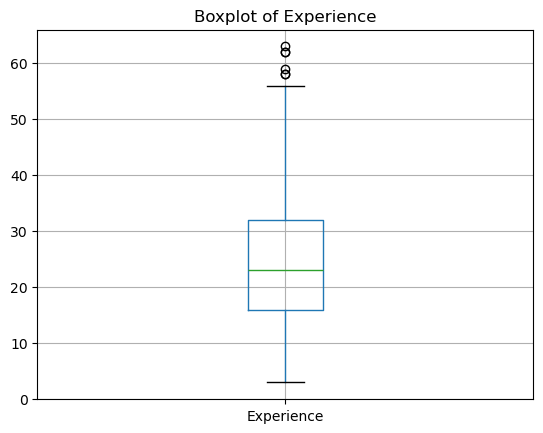

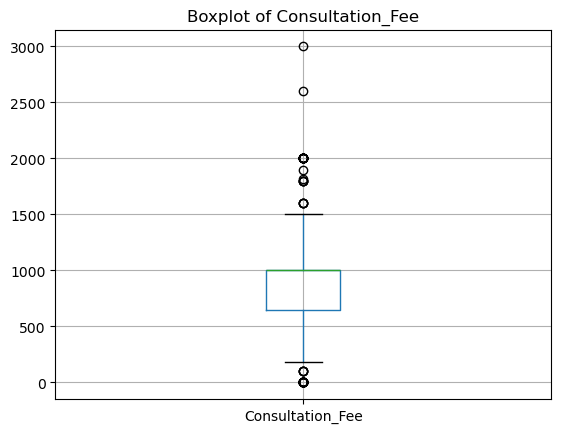

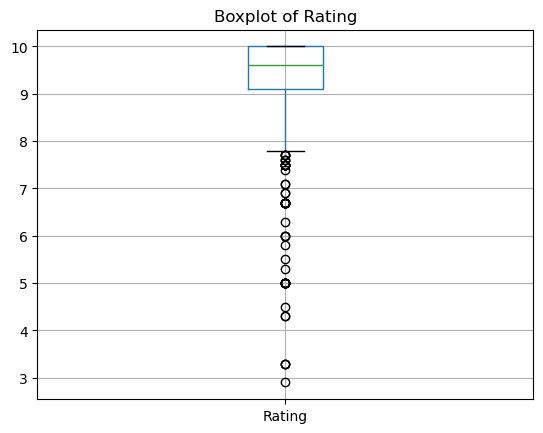

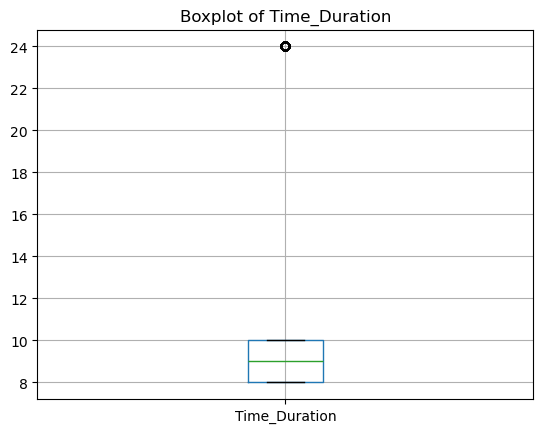

In [39]:
numeric_cols = ["Experience", "Consultation_Fee", "Rating", "Time_Duration"]

for col in numeric_cols:
    plt.figure()
    df.boxplot(column=col)
    plt.title(f"Boxplot of {col}")
    plt.show()

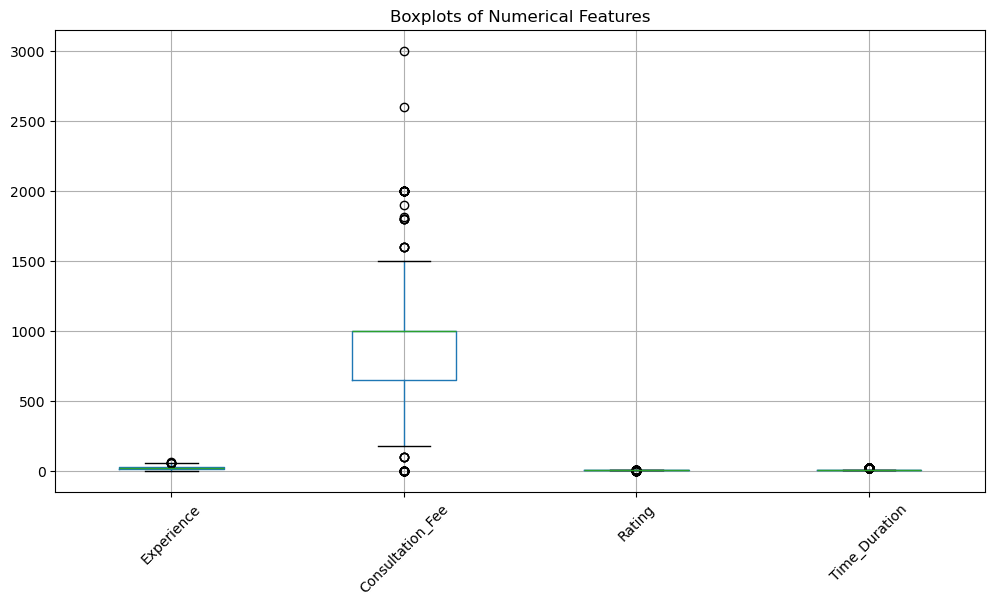

In [40]:
# Numeric columns in your cleaned dataset
cols_to_plot = ["Experience", "Consultation_Fee", "Rating", "Time_Duration"]

plt.figure(figsize=(12,6))
df[cols_to_plot].boxplot()

plt.xticks(rotation=45)
plt.title("Boxplots of Numerical Features")
plt.show()

### Observation

- Outliers were identified in **Experience (4)**, **Consultation_Fee (65)**, **Rating (56)**, and **Time_Duration (133)**.
- These extreme values lie outside the normal range of the data distribution.
- The outliers were **treated using capping**, where values beyond the lower and upper limits were replaced with the respective boundary values.
- This helped reduce the impact of extreme values while preserving the overall dataset size.

### Why Outliers Were Not Removed

Outliers in **Experience, Consultation_Fee, Rating, and Time_Duration** were not removed because they represent **real-world variations in healthcare services rather than data errors**. Removing them could lead to loss of important information and misrepresentation of the dataset.

#### Experience
- Doctors may have a wide range of professional experience.
- Some senior doctors may have **30–40+ years of experience**, which naturally appears as outliers.
- These values represent **highly experienced medical professionals**.

**Explanation:**  
Removing these values would hide the presence of **senior and highly experienced doctors**, which is important for healthcare analysis.

---

#### Consultation Fee
- Consultation fees vary depending on **doctor experience, hospital reputation, specialization, and location**.
- Some hospitals provide **free consultations (₹0)** as part of promotions or public healthcare services.
- Highly specialized doctors or premium hospitals may charge **higher consultation fees (₹2000–₹3000)**.

**Explanation:**  
These values reflect **actual pricing differences in healthcare services**. Removing them would distort the **true affordability analysis**.

---

#### Rating
- Ratings are based on **patient feedback and satisfaction**.
- Some hospitals may receive **very high or very low ratings** due to patient experiences.
- These variations reflect **real user opinions**.

**Explanation:**  
Removing these values would **misrepresent the actual distribution of patient satisfaction levels**.

---

#### Time Duration
- Some hospitals operate **24 hours**, especially **emergency and multi-specialty hospitals**.
- Smaller clinics may operate only **a few hours per day**, while larger hospitals may have **extended consultation hours**.

**Explanation:**  
These values represent **real hospital operating hours**. Removing them would misrepresent the **actual accessibility and availability of healthcare services**.

In [41]:
df

,Doctor_Name,Specialization,Experience,Locality,City,Hospital_Name,Consultation_Fee,Rating,Working_Hours,Timing_Category,Time_Duration
0,Dr. Vandana Hegde,Infertility Specialist,23,Madhapur,Hyderabad,Hegde Hospital,800.0,9.3,9:00 AM - 6:00 PM,Morning,9.0
1,Dr. Soumya H R,Reproductive Endocrinologist (Infertility),8,Madhapur,Hyderabad,Hegde Hospital,600.0,9.6,24x7,24x7,24.0
2,Dr. Akshita Agarwal,Gynecologist/Obstetrician,9,Madhapur,Hyderabad,Hegde Hospital,600.0,9.6,10:00 AM - 8:00 PM,Morning,10.0
3,Dr. Jasmine Ramesh Salkar,Gynecologist/Obstetrician,23,Madhapur,Hyderabad,Hegde Hospital,800.0,9.5,8:00 AM - 4:00 PM,Morning,8.0
4,Dr. B C Mounica,Gynecologist/Obstetrician,10,Madhapur,Hyderabad,Hegde Hospital,600.0,9.6,10:00 AM - 8:00 PM,Morning,10.0
...,...,...,...,...,...,...,...,...,...,...,...
592,Dr. Anup Agrawal,Internal Medicine,19,Shankar Nagar,Nagpur,Wockhardt Super Speciality Hospital,1000.0,9.6,9:00 AM - 6:00 PM,Morning,9.0
593,Dr. Shivani Dilip Deshpande,Gynecologist/Obstetrician,21,Shankar Nagar,Nagpur,Wockhardt Super Speciality Hospital,1000.0,9.6,10:00 AM - 8:00 PM,Morning,10.0
594,Dr. Chetan Sharma,Anesthesiologist,21,Shankar Nagar,Nagpur,Wockhardt Super Speciality Hospital,1200.0,9.6,11:00 AM - 7:00 PM,Morning,8.0
595,Dr. Siddhartha Saoji,Ear-Nose-Throat (ENT) Specialist,17,Shankar Nagar,Nagpur,Wockhardt Super Speciality Hospital,1000.0,10.0,24x7,24x7,24.0


### univariate analysis

In [42]:
df["Hospital_Name"].value_counts().head(10)

Hospital_Name
Cloudnine Hospital                            58
Motherhood Hospital                           45
Manipal Hospitals                             32
Manipal Hospital                              30
Apollo Hospital                               20
Wockhardt Super Speciality Hospital           19
DHI Hair Transplant and Restoration Clinic    18
Be Well Hospital                              15
Shantiraj Hospitals                           12
SCI International Hospital                    10
Name: count, dtype: int64

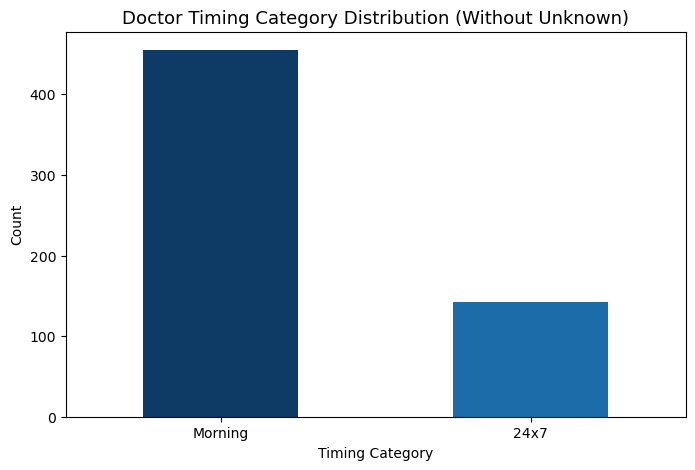

In [43]:
plt.figure(figsize=(8,5))

colors = ["#0D3B66", "#1B6CA8", "#2A9D8F", "#52B788", "#74C69D"]

df[df["Timing_Category"] != "Unknown"]["Timing_Category"] \
    .value_counts() \
    .plot(kind="bar", color=colors)

plt.title("Doctor Timing Category Distribution (Without Unknown)", fontsize=13)
plt.xlabel("Timing Category")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

### Observation: Doctor Timing Category Distribution

- The majority of hospitals operate during the **Morning shift**, with a significantly higher count compared to other categories.
- A smaller number of hospitals provide **24×7 services**, indicating limited round-the-clock healthcare availability.
- This suggests that most healthcare facilities follow **regular daytime consultation hours**, while only a few hospitals offer **continuous emergency or full-day services**.
- The presence of 24×7 hospitals is important as they ensure **access to medical care during emergencies and non-standard hours**.

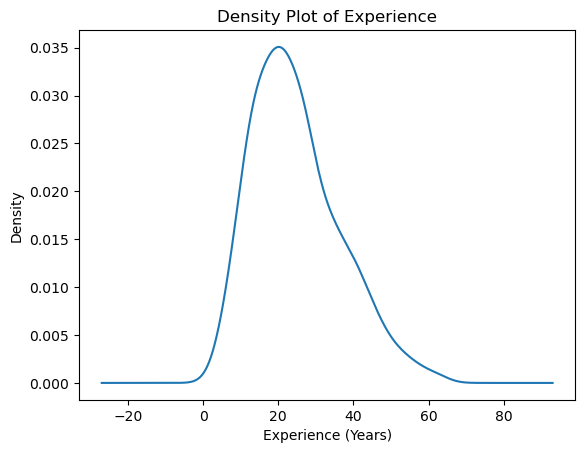

In [44]:
plt.figure()
df["Experience"].plot(kind="density")
plt.title("Density Plot of Experience")
plt.xlabel("Experience (Years)")
plt.show()

### Observation: Density Plot of Doctor Experience

- The distribution of **doctor experience** appears **right-skewed (positively skewed)**.
- Most doctors have experience concentrated between **15 to 30 years**, where the density is highest.
- The peak of the curve occurs around **20 years**, indicating that many doctors in the dataset have moderate professional experience.
- A smaller number of doctors have **very high experience (above 40–50 years)**, which creates the long right tail in the distribution.
- This suggests that the healthcare workforce mainly consists of **mid-career professionals**, with fewer extremely senior doctors.

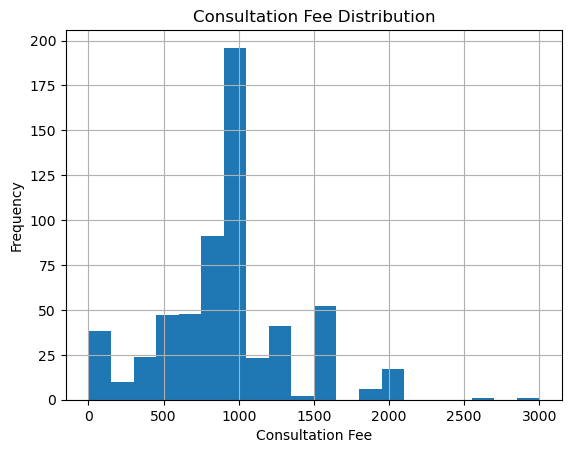

In [45]:
plt.figure()
df["Consultation_Fee"].hist(bins=20)
plt.title("Consultation Fee Distribution")
plt.xlabel("Consultation Fee")
plt.ylabel("Frequency")
plt.show()

### Observation: Consultation Fee Distribution

- The **consultation fee distribution is positively skewed (right-skewed)**.
- Most consultation fees are concentrated between **₹500 and ₹1000**, indicating that this is the common price range for doctor consultations.
- A small number of hospitals or specialists charge **higher fees (₹1500–₹3000)**, creating the long right tail in the distribution.
- There are also **very low or zero consultation fees**, which may represent free consultations or promotional services.
- Overall, the distribution shows that while **moderate consultation fees are most common**, there is significant variation depending on the hospital, specialization, and service quality.

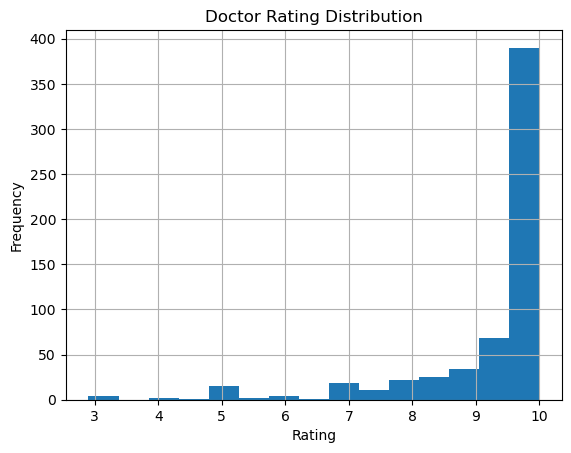

In [46]:
plt.figure()
df["Rating"].dropna().hist(bins=15)
plt.title("Doctor Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

### Observation: Doctor Rating Distribution

- The **rating distribution is negatively skewed (left-skewed)**.
- Most doctors have ratings between **9 and 10**, indicating very high patient satisfaction.
- A smaller number of doctors have **moderate ratings between 7 and 8**.
- Very few doctors have **low ratings below 6**, which appear as a small tail on the left side of the distribution.
- Overall, the dataset suggests that **most hospitals and doctors receive very positive ratings from patients**, with only a limited number receiving lower feedback.

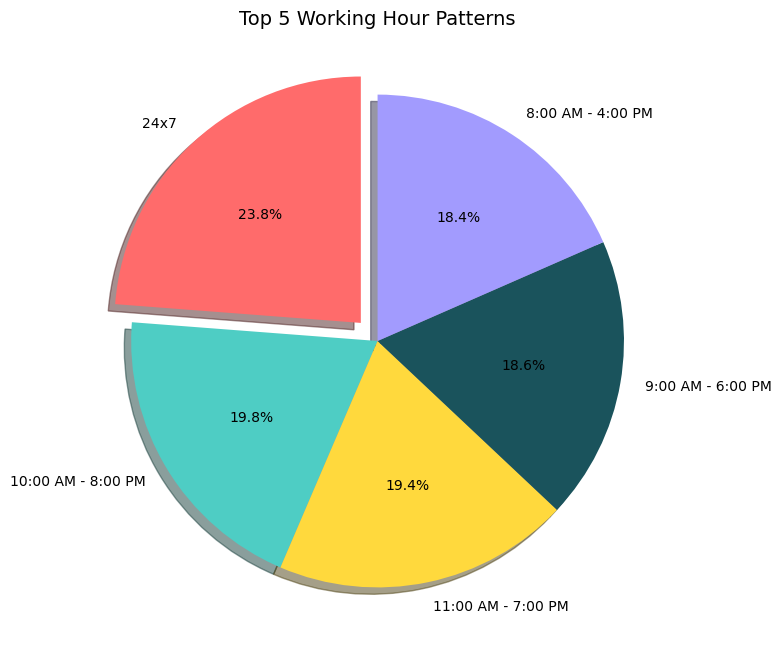

In [47]:
plt.figure(figsize=(8,8))

top_hours = df["Working_Hours"].value_counts().head(5)

explode = [0.1 if "24" in str(i) else 0 for i in top_hours.index]

colors = ["#FF6B6B", "#4ECDC4", "#FFD93D", "#1A535C", "#A29BFE"]

top_hours.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    shadow=True,
    explode=explode,
    colors=colors[:len(top_hours)]
)

plt.title("Top 5 Working Hour Patterns", fontsize=14)
plt.ylabel("")
plt.show()

### Observation

- **24x7 availability** has the highest share at **24.4%**, indicating many doctors offer round-the-clock consultation.
- **8:00 AM – 4:00 PM** accounts for **20.5%** of the working hours.
- **11:00 AM – 7:00 PM** and **9:00 AM – 6:00 PM** have similar distributions at **19.4%** and **19.3%** respectively.
- **10:00 AM – 8:00 PM** has the lowest share among the top patterns at **16.4%**.

## bivariate analysis

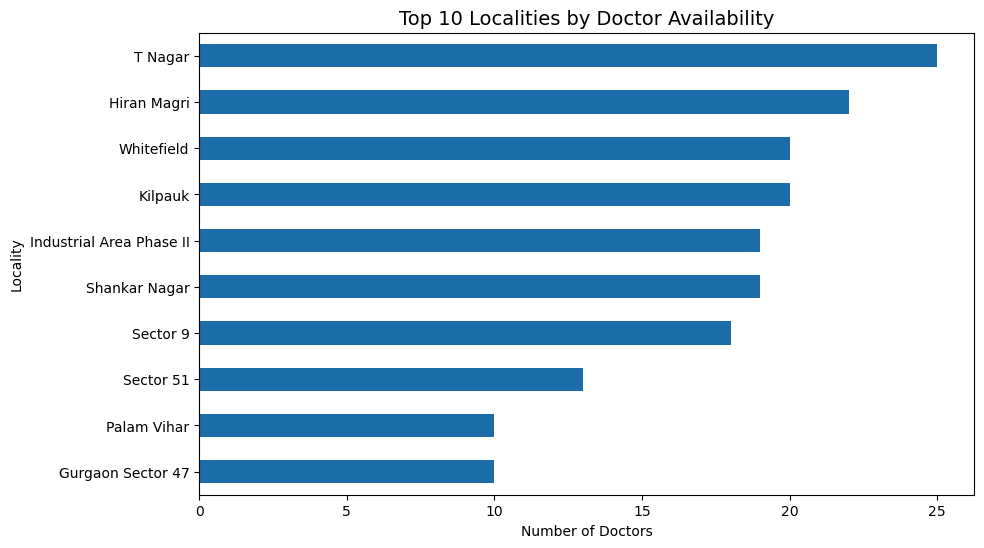

In [48]:
plt.figure(figsize=(10,6))

top_localities = df["Locality"].value_counts().head(10)

top_localities.sort_values().plot(
    kind="barh",
    color="#1B6CA8"
)

plt.title("Top 10 Localities by Doctor Availability", fontsize=14)
plt.xlabel("Number of Doctors")
plt.ylabel("Locality")
plt.show()

In [49]:
# T Nagar (Chennai)
# Whitefield (Bangalore)
# Kilpauk (Chennai)
# Sector 9 (Chandigarh)
# Sector 51 (Noida)
# Hiran Magri (Udaipur)
# Teynampet (Chennai)
# Manapakkam (Chennai)
# Alwarpet (Chennai)
# Greams Road (Chennai)

### Observation

- **T Nagar** has the highest doctor availability with about **30 doctors**.
- **Whitefield** and **Kilpauk** follow with around **20 doctors each**.
- **Sector 9** and **Sector 51** show moderate availability with about **14 doctors**.
- The remaining localities such as **Hiran Magri, Teynampet, Manapakkam, Alwarpet, and Greams Road** have around **10–11 doctors** each.

<Figure size 1000x600 with 0 Axes>

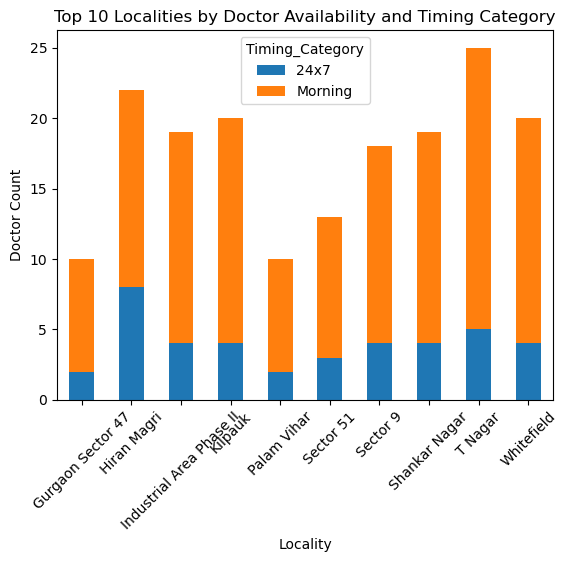

In [50]:
# Get top 10 localities by doctor count
top_localities = df["Locality"].value_counts().head(10).index

# Filter dataset
top_df = df[df["Locality"].isin(top_localities)]

# Count timing categories
timing_counts = top_df.groupby(["Locality", "Timing_Category"]).size().unstack(fill_value=0)

# Plot
plt.figure(figsize=(10,6))
timing_counts.plot(kind="bar", stacked=True)

plt.title("Top 10 Localities by Doctor Availability and Timing Category")
plt.xlabel("Locality")
plt.ylabel("Doctor Count")

plt.xticks(rotation=45)
plt.show()

### Observation: Top 10 Localities by Doctor Availability and Timing Category

- The chart shows the **top 10 localities across different cities** based on the number of available doctors and their **timing categories (Morning and 24x7)**.
- **T Nagar (Chennai)** has the **highest doctor availability**, with a large number of doctors working mainly during the **Morning shift** and a smaller portion providing **24x7 services**.
- **Whitefield (Bangalore)** and **Kilpauk (Chennai)** also show **high doctor availability**, indicating strong healthcare presence in these urban areas.
- Localities such as **Sector 9 and Sector 51 (Noida)** and **Hiran Magri (Udaipur)** show **moderate doctor availability**, suggesting developing healthcare infrastructure.
- Across most localities, the **Morning timing category dominates**, meaning most doctors provide services during regular daytime hours.
- Only a **small proportion of doctors offer 24x7 availability**, indicating that round-the-clock medical services are limited to fewer hospitals or clinics.
- Overall, the visualization highlights how **doctor availability varies across cities and localities**, reflecting differences in **healthcare accessibility and service availability**.

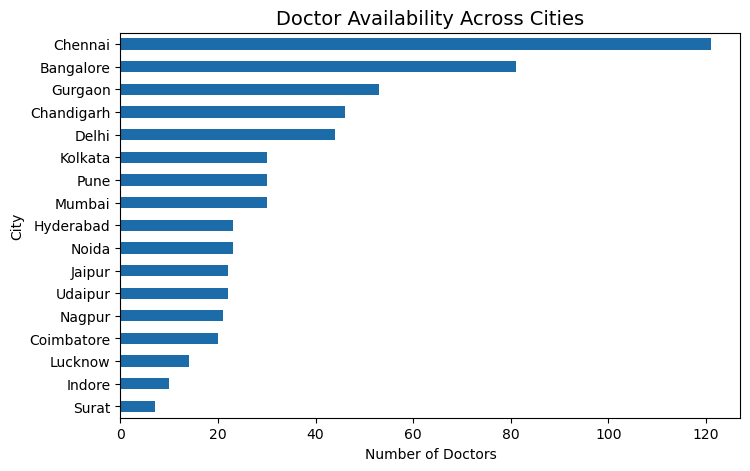

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df["City"].value_counts().sort_values().plot(
    kind="barh",
    color="#1B6CA8"
)

plt.title("Doctor Availability Across Cities", fontsize=14)
plt.xlabel("Number of Doctors")
plt.ylabel("City")
plt.show()

### Observation: Doctor Availability Across Cities

- The chart shows the **distribution of doctor availability across different cities**.
- **Chennai** has the **highest number of doctors**, indicating a strong healthcare infrastructure and higher concentration of hospitals and clinics.
- **Bangalore** and **Gurgaon** also show **high doctor availability**, suggesting these cities are major healthcare hubs.
- **Delhi** follows with a moderate number of doctors, reflecting its large urban population and healthcare demand.
- Cities like **Pune, Kolkata, and Chandigarh** show **moderate doctor availability**, indicating stable healthcare services.
- **Mumbai, Noida, Hyderabad, and Jaipur** have slightly lower counts but still maintain a reasonable presence of healthcare professionals.
- Smaller cities such as **Nagpur, Udaipur, Indore, and Surat** show **lower doctor availability**, which may indicate limited healthcare facilities compared to larger metropolitan areas.

**Overall Insight:**  
Doctor availability is **concentrated mainly in major metropolitan cities**, highlighting disparities in healthcare access between large urban centers and smaller cities.

<Figure size 800x500 with 0 Axes>

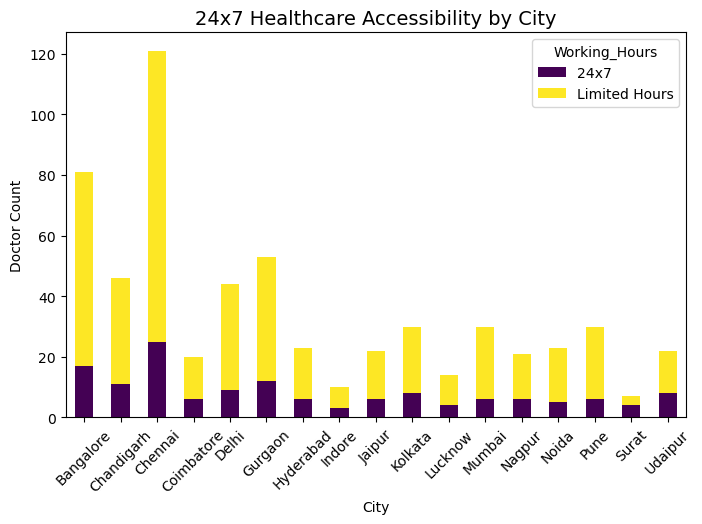

In [52]:
plt.figure(figsize=(8,5))

availability = df["Working_Hours"].apply(
    lambda x: "24x7" if "24" in str(x) else "Limited Hours"
)

city_access = pd.crosstab(df["City"], availability)

city_access.plot(
    kind="bar",
    stacked=True,
    colormap="viridis",
    figsize=(8,5)
)

plt.title("24x7 Healthcare Accessibility by City", fontsize=14)
plt.xlabel("City")
plt.ylabel("Doctor Count")
plt.xticks(rotation=45)
plt.show()

### Observation: 24x7 Healthcare Accessibility by City

- The chart compares **24x7 healthcare availability** with **limited-hour healthcare services** across different cities.
- **Chennai** has the **highest number of healthcare facilities overall**, including the largest number of **24x7 services**, indicating strong healthcare accessibility.
- **Bangalore** and **Gurgaon** also show relatively **higher 24x7 availability**, suggesting better emergency healthcare support in these metropolitan areas.
- In most cities, the number of facilities operating with **limited hours is significantly higher than 24x7 services**.
- Cities such as **Delhi, Pune, and Noida** show moderate healthcare availability but still have fewer **round-the-clock services**.
- Smaller cities like **Surat, Udaipur, and Indore** have **lower counts of both 24x7 and limited-hour facilities**, indicating comparatively limited healthcare infrastructure.

**Overall Insight:**  
While healthcare facilities are widely available across cities, **24x7 healthcare services are limited compared to regular working-hour facilities**, highlighting potential gaps in **emergency healthcare accessibility in several cities**.

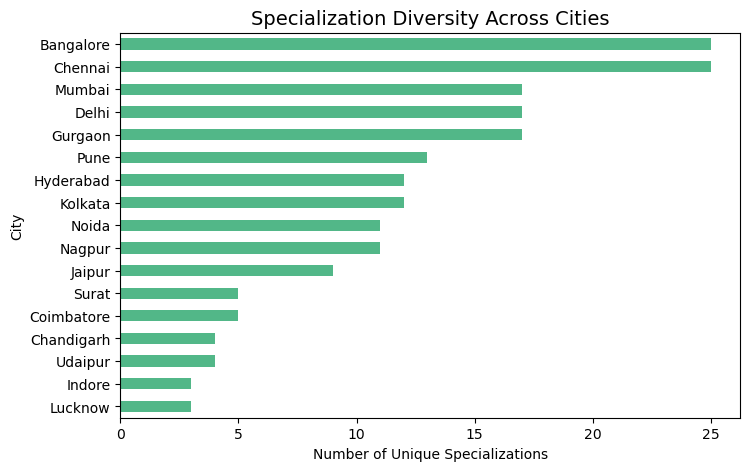

In [53]:
plt.figure(figsize=(8,5))

df.groupby("City")["Specialization"].nunique() \
    .sort_values() \
    .plot(kind="barh", color="#52B788")

plt.title("Specialization Diversity Across Cities", fontsize=14)
plt.xlabel("Number of Unique Specializations")
plt.ylabel("City")
plt.show()

### 




Observation: Specialization Diversity Across Cities

- The chart illustrates the **number of unique medical specializations available across different cities**.
- **Chennai** and **Bangalore** have the **highest specialization diversity**, indicating well-developed healthcare ecosystems with a wide range of medical services.
- **Gurgaon** also shows a relatively high number of specializations, suggesting strong healthcare infrastructure in the region.
- Cities such as **Mumbai, Pune, Kolkata, Hyderabad, and Delhi** demonstrate **moderate specialization diversity**, reflecting balanced availability of healthcare services.
- **Noida, Nagpur, and Jaipur** show slightly lower but still reasonable levels of specialization coverage.
- Smaller cities like **Coimbatore, Surat, Udaipur, Chandigarh, Lucknow, and Indore** have **fewer unique specializations**, which may indicate limited access to specialized healthcare services.

**Overall Insight:**  
Major metropolitan cities tend to offer **greater diversity in medical specializations**, while smaller cities show **more limited specialization availability**, highlighting potential disparities in access to specialized healthcare services.

<Figure size 1200x600 with 0 Axes>

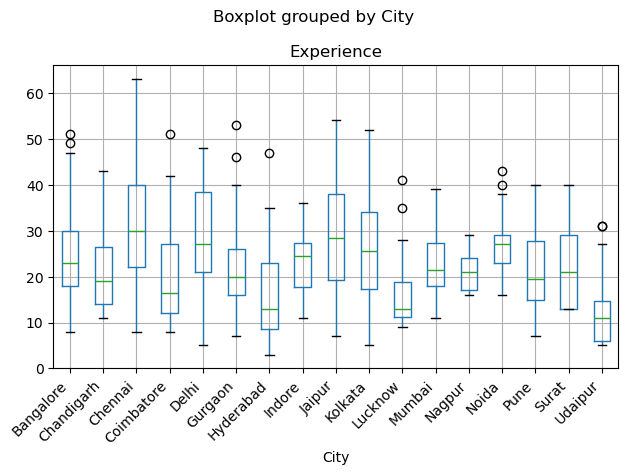

In [54]:
top_cities = df["City"].value_counts().index

plt.figure(figsize=(12,6))

df.boxplot(column="Experience", by="City")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Observation: Doctor Experience Distribution Across Cities

- The boxplot shows the **distribution of doctor experience across different cities**.
- **Chennai, Delhi, and Jaipur** display a **higher median experience**, indicating that many doctors in these cities have substantial professional experience.
- Cities such as **Bangalore, Kolkata, and Pune** show **moderate experience levels**, with a balanced spread of junior and experienced doctors.
- **Hyderabad, Lucknow, and Udaipur** tend to have **lower median experience**, suggesting a larger proportion of relatively newer doctors.
- Several cities show **outliers with very high experience**, representing senior doctors with many years of practice.
- The spread of the boxes indicates **variation in experience levels within each city**, reflecting a mix of early-career and highly experienced healthcare professionals.

**Overall Insight:**  
Doctor experience varies across cities, but most cities show a **balanced mix of moderately experienced and highly experienced doctors**, contributing to diverse healthcare expertise across regions.

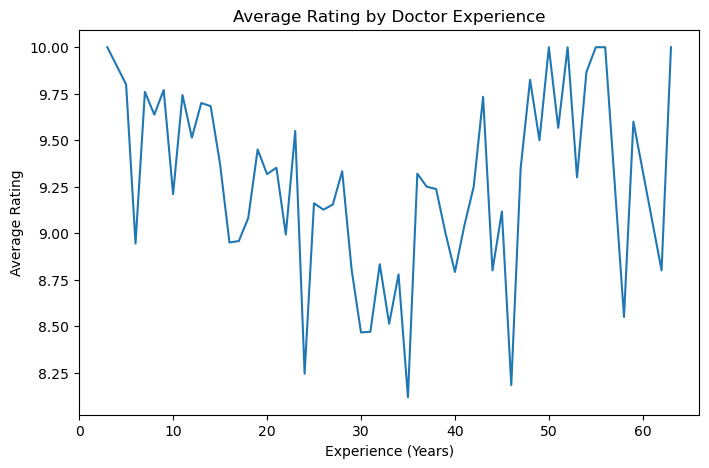

In [55]:
plt.figure(figsize=(8,5))

avg_rating = df.groupby("Experience")["Rating"].mean()

plt.plot(avg_rating)

plt.xlabel("Experience (Years)")
plt.ylabel("Average Rating")
plt.title("Average Rating by Doctor Experience")

plt.show()

### Observation: Average Rating by Doctor Experience

- The chart shows the **relationship between doctor experience and average patient ratings**.
- Doctors with **lower to moderate experience (around 5–20 years)** generally maintain **high ratings close to 9–10**, indicating strong patient satisfaction.
- As experience increases, the **ratings remain consistently high**, suggesting that both mid-career and highly experienced doctors receive positive feedback.
- Some fluctuations are visible at certain experience levels, but **ratings rarely drop below 8**, showing overall positive evaluations.
- Highly experienced doctors (above **40 years of experience**) still maintain **very high ratings**, indicating continued trust and patient confidence.

**Overall Insight:**  
Doctor experience does not significantly reduce patient satisfaction; instead, **doctors across all experience levels tend to receive high ratings**, reflecting generally positive healthcare service quality.

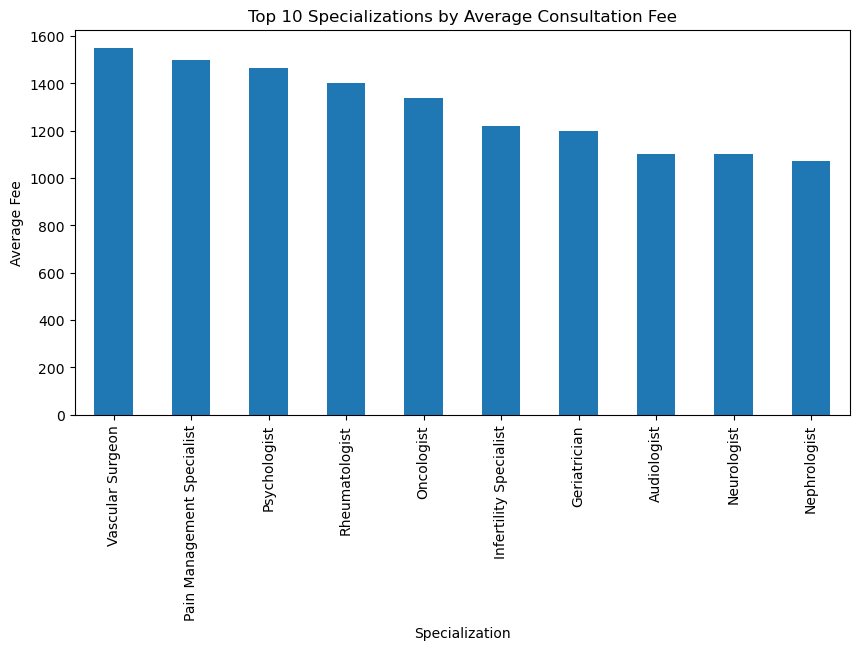

In [56]:
avg_fee = df.groupby("Specialization")["Consultation_Fee"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
avg_fee.plot(kind="bar")

plt.title("Top 10 Specializations by Average Consultation Fee")
plt.ylabel("Average Fee")
plt.xlabel("Specialization")

plt.show()

### Observation: Top 10 Specializations by Average Consultation Fee

- The chart highlights the **top medical specializations with the highest average consultation fees**.
- **Vascular Surgeons** have the **highest average consultation fee**, indicating the specialized and complex nature of vascular treatments.
- **Pain Management Specialists** and **Psychologists** also show relatively high consultation fees, reflecting the expertise and specialized care required in these fields.
- Specializations such as **Oncologists** and **Infertility Specialists** have high consultation fees due to the complexity of treatments and advanced medical knowledge involved.
- **Geriatricians, Neurologists, and Internal Medicine specialists** have moderately high consultation fees, as they handle a wide range of complex health conditions.
- **Nephrologists and Pulmonologists** also appear in the top 10, reflecting the demand for specialists dealing with kidney and respiratory-related diseases.

**Overall Insight:**  
Highly specialized medical fields tend to have **higher consultation fees**, which may reflect the **complexity of treatments, advanced expertise required, and demand for specialized healthcare services**.

## multi variate analysis

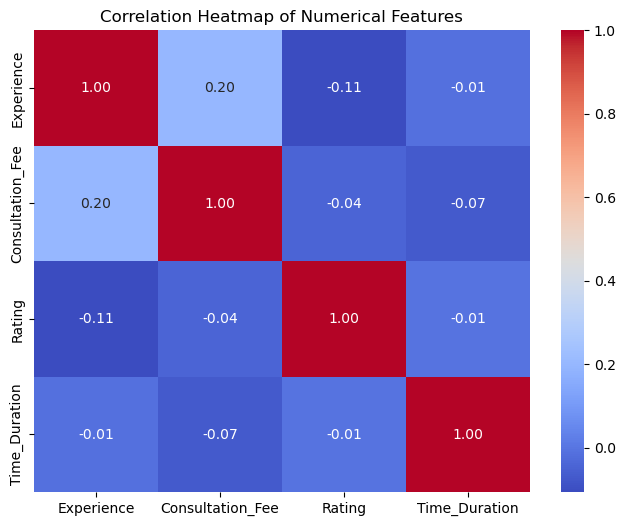

In [57]:
plt.figure(figsize=(8,6))

numeric_cols = ["Experience","Consultation_Fee","Rating","Time_Duration"]

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

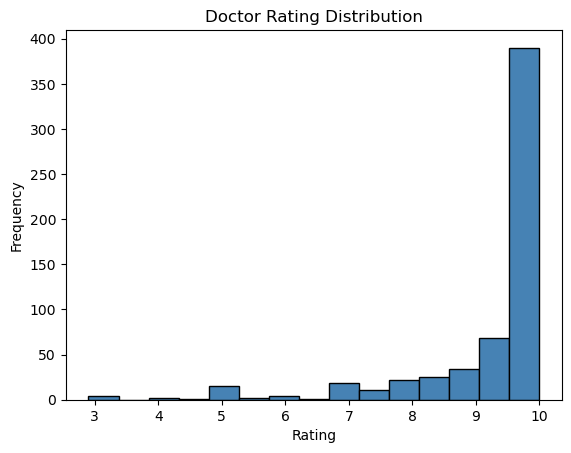

In [58]:
df['Rating'].dropna().plot(kind='hist', bins=15, color='steelblue', 
                            edgecolor='black', title='Doctor Rating Distribution')
plt.xlabel('Rating')
plt.show()

### Key Observations
1. Heavily Right-Skewed Distribution

The vast majority of doctors are rated close to 10
Rating 10 has ~385 doctors — by far the most frequent value
Very few doctors have ratings below 7

2. Rating 10 Dominates

Nearly 400 doctors have a perfect 10 rating
This is unusually high and suggests possible data quality issues or a biased rating system


In [60]:
# Filter only Hyderabad
hyd_df = df[df['City'] == 'Hyderabad']

print(f"Total doctors in Hyderabad: {len(hyd_df)}")

Total doctors in Hyderabad: 23


In [61]:
# Top specializations in Hyderabad
print("=== Top Specializations ===")
print(hyd_df['Specialization'].value_counts())

# Average consultation fee
print("\n=== Consultation Fee Stats ===")
print(hyd_df['Consultation_Fee'].describe())

# Top rated doctors
print("\n=== Top 5 Rated Doctors ===")
top = hyd_df[['Doctor_Name', 'Specialization', 'Rating', 'Consultation_Fee']]
print(top.sort_values('Rating', ascending=False).head())

# Timing category distribution
print("\n=== Timing Category ===")
print(hyd_df['Timing_Category'].value_counts())

# Hospitals in Hyderabad
print("\n=== Hospitals ===")
print(hyd_df['Hospital_Name'].value_counts())

# Locality wise doctor count
print("\n=== Doctors per Locality ===")
print(hyd_df['Locality'].value_counts())

=== Top Specializations ===
Specialization
Gynecologist/Obstetrician                     6
General Surgeon                               3
General Physician                             3
Pediatrician                                  2
Orthopedist                                   2
Infertility Specialist                        1
Reproductive Endocrinologist (Infertility)    1
Oncologist                                    1
Acupressure                                   1
Acupuncturist                                 1
Urologist                                     1
Ear-Nose-Throat (ENT) Specialist              1
Name: count, dtype: int64

=== Consultation Fee Stats ===
count     23.000000
mean     489.130435
std      196.536211
min        0.000000
25%      300.000000
50%      500.000000
75%      600.000000
max      800.000000
Name: Consultation_Fee, dtype: float64

=== Top 5 Rated Doctors ===
                        Doctor_Name             Specialization  Rating  \
7                    

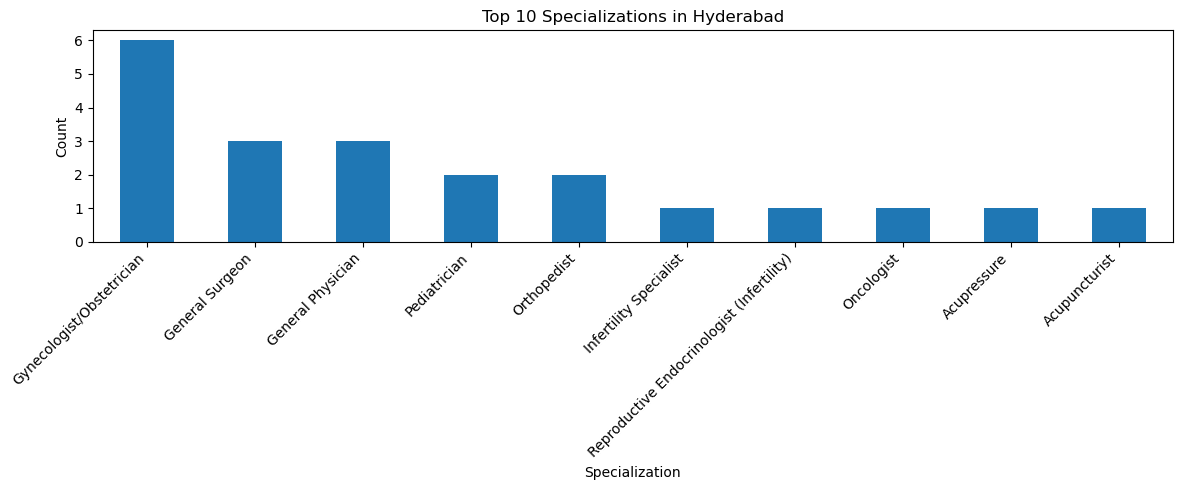

In [62]:
import matplotlib.pyplot as plt

# Specialization count bar chart
hyd_df['Specialization'].value_counts().head(10).plot(kind='bar', figsize=(12,5))
plt.title('Top 10 Specializations in Hyderabad')
plt.xlabel('Specialization')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()